In [52]:
#Phase 1: Load data and verify it imported correctly.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Added this import

# Load
df = pd.read_csv('Pharma_Industry.csv')

# Check: Confirming Data looks right
print(df.shape)      # Rows x Columns
print(df.head())     # First 5 rows
print(df.tail())     # Last 5 rows (check for summary footer rows)
print(df.info())     # Dtypes and Non-Null counts

(500, 6)
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  
     Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
495         -1.553759

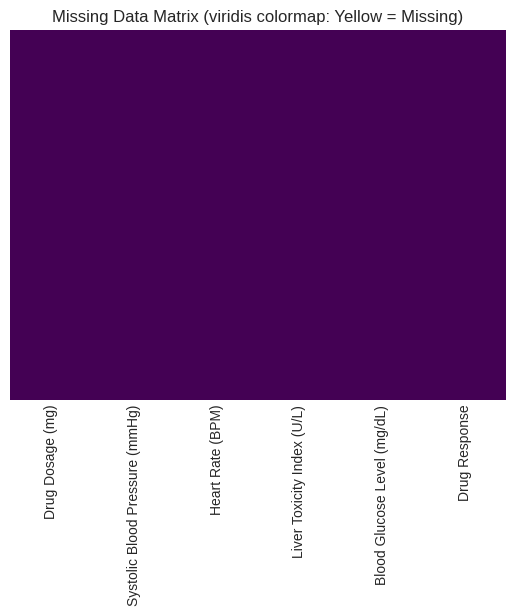

No missing values found in the dataset.

Descriptive Statistics:
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count            500.00                          500.00            500.00   
mean              -0.04                            0.21              0.06   
std                0.98                            1.25              0.97   
min               -3.02                           -3.77             -2.94   
25%               -0.64                           -0.57             -0.65   
50%               -0.02                            0.20              0.03   
75%                0.64                            0.95              0.71   
max                2.95                            4.11              3.19   

       Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
count                      500.00                       500.00         500.00  
mean                         0.05                        -0.17           0.52  
s

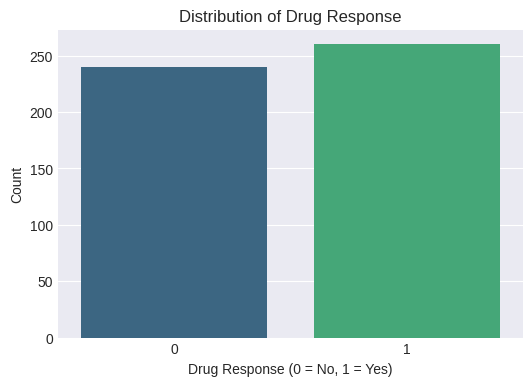


Class Distribution of 'Drug Response':
Drug Response
1    260
0    240
Name: count, dtype: int64

Percentage of Class 0: 48.00%
Percentage of Class 1: 52.00%


In [53]:
#Phase 3: Missing Value Analysis

#Visual Method (Heatmap):
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Matrix (viridis colormap: Yellow = Missing)")
plt.show()

#Statistical Method:
missing_perc = df.isnull().sum() / len(df) * 100
if missing_perc[missing_perc > 0].empty:
    print("No missing values found in the dataset.")
else:
    print("\nPercentage of Missing Values:")
    print(missing_perc[missing_perc > 0].sort_values(ascending=False))
print("\nDescriptive Statistics:")
print(df.describe().round(2))

# Class Distribution Analysis for 'Drug Response'
plt.figure(figsize=(6, 4))
sns.countplot(x='Drug Response', data=df, hue='Drug Response', palette='viridis', legend=False)
plt.title('Distribution of Drug Response')
plt.xlabel('Drug Response (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print("\nClass Distribution of 'Drug Response':")
print(df['Drug Response'].value_counts())
print(f"\nPercentage of Class 0: {(df['Drug Response'].value_counts()[0] / len(df) * 100):.2f}%")
print(f"Percentage of Class 1: {(df['Drug Response'].value_counts()[1] / len(df) * 100):.2f}%")

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
#Phase 2: Structure & Data Types
#Data Preprocessing - Encoding Categorical Variables

# Based on the "Feature Types and Cardinality Analysis" in Phase 2, the dataset contains one categorical variable, `Drug Response`, which is already numerically encoded as `0` and `1`. Therefore, no explicit encoding steps like One-Hot Encoding or Label Encoding are immediately required for this feature at this stage.

# All other features are continuous numerical variables.

# Identify column types and cardinality
print("\n Feature Types and Cardinality Analysis:\n")

# Get all column names
all_cols = df.columns

cardinality_info = {}

for col in all_cols:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    total_rows = len(df)
    perc_unique = (nunique / total_rows) * 100

    cardinality_info[col] = {
        'Dtype': dtype,
        'Unique Values': nunique,
        '% Unique': f'{perc_unique:.2f}%'
    }

    print(f"- {col}:")
    print(f"  Data Type: {dtype}")
    print(f"  Unique Values: {nunique} ( {perc_unique:.2f}% of total rows)")

    # Provide insights based on cardinality and type
    if dtype == 'object':
        if nunique <= 10: # Arbitrary threshold for low cardinality object
            print("  -> Likely a categorical feature (low cardinality object type).")
        else:
            print("  -> High cardinality object type, potentially text or identifiers.")
    elif pd.api.types.is_numeric_dtype(dtype): # Check if it's a numeric type
        if nunique == 2:
            print("  -> Binary categorical feature (e.g., 0/1, True/False).")
        elif nunique <= 20: # Arbitrary threshold for numerical that might be categorical
            print("  -> Potentially a categorical feature (numeric with low unique values).")
        else:
            print("  -> Likely a continuous numerical feature (high unique values).")
    print("\n")

# Confirm current data types and unique values
print("Current Data Types:")
print(df.info())

print("\nUnique values for 'Drug Response':")
print(df['Drug Response'].value_counts())

# Optional: Display a summary DataFrame of cardinality
print("\nSummary of Feature Cardinality:")
cardinality_df = pd.DataFrame.from_dict(cardinality_info, orient='index')
print(cardinality_df.sort_values(by='Unique Values', ascending=True).to_string())

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Data Split:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set: {X_test.shape[0]} samples")

# Feature scaling (CRITICAL for SVM!)
print("\n Scaling features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete")

print(f"\nDataset split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nValue counts for y_train:")
print(y_train.value_counts(normalize=True))
print("\nValue counts for y_test:")
print(y_test.value_counts(normalize=True))


 Feature Types and Cardinality Analysis:

- Drug Dosage (mg):
  Data Type: float64
  Unique Values: 500 ( 100.00% of total rows)
  -> Likely a continuous numerical feature (high unique values).


- Systolic Blood Pressure (mmHg):
  Data Type: float64
  Unique Values: 500 ( 100.00% of total rows)
  -> Likely a continuous numerical feature (high unique values).


- Heart Rate (BPM):
  Data Type: float64
  Unique Values: 500 ( 100.00% of total rows)
  -> Likely a continuous numerical feature (high unique values).


- Liver Toxicity Index (U/L):
  Data Type: float64
  Unique Values: 500 ( 100.00% of total rows)
  -> Likely a continuous numerical feature (high unique values).


- Blood Glucose Level (mg/dL):
  Data Type: float64
  Unique Values: 500 ( 100.00% of total rows)
  -> Likely a continuous numerical feature (high unique values).


- Drug Response:
  Data Type: int64
  Unique Values: 2 ( 0.40% of total rows)
  -> Binary categorical feature (e.g., 0/1, True/False).


Current Data Ty


 Creating distribution plots for 6 numerical features...


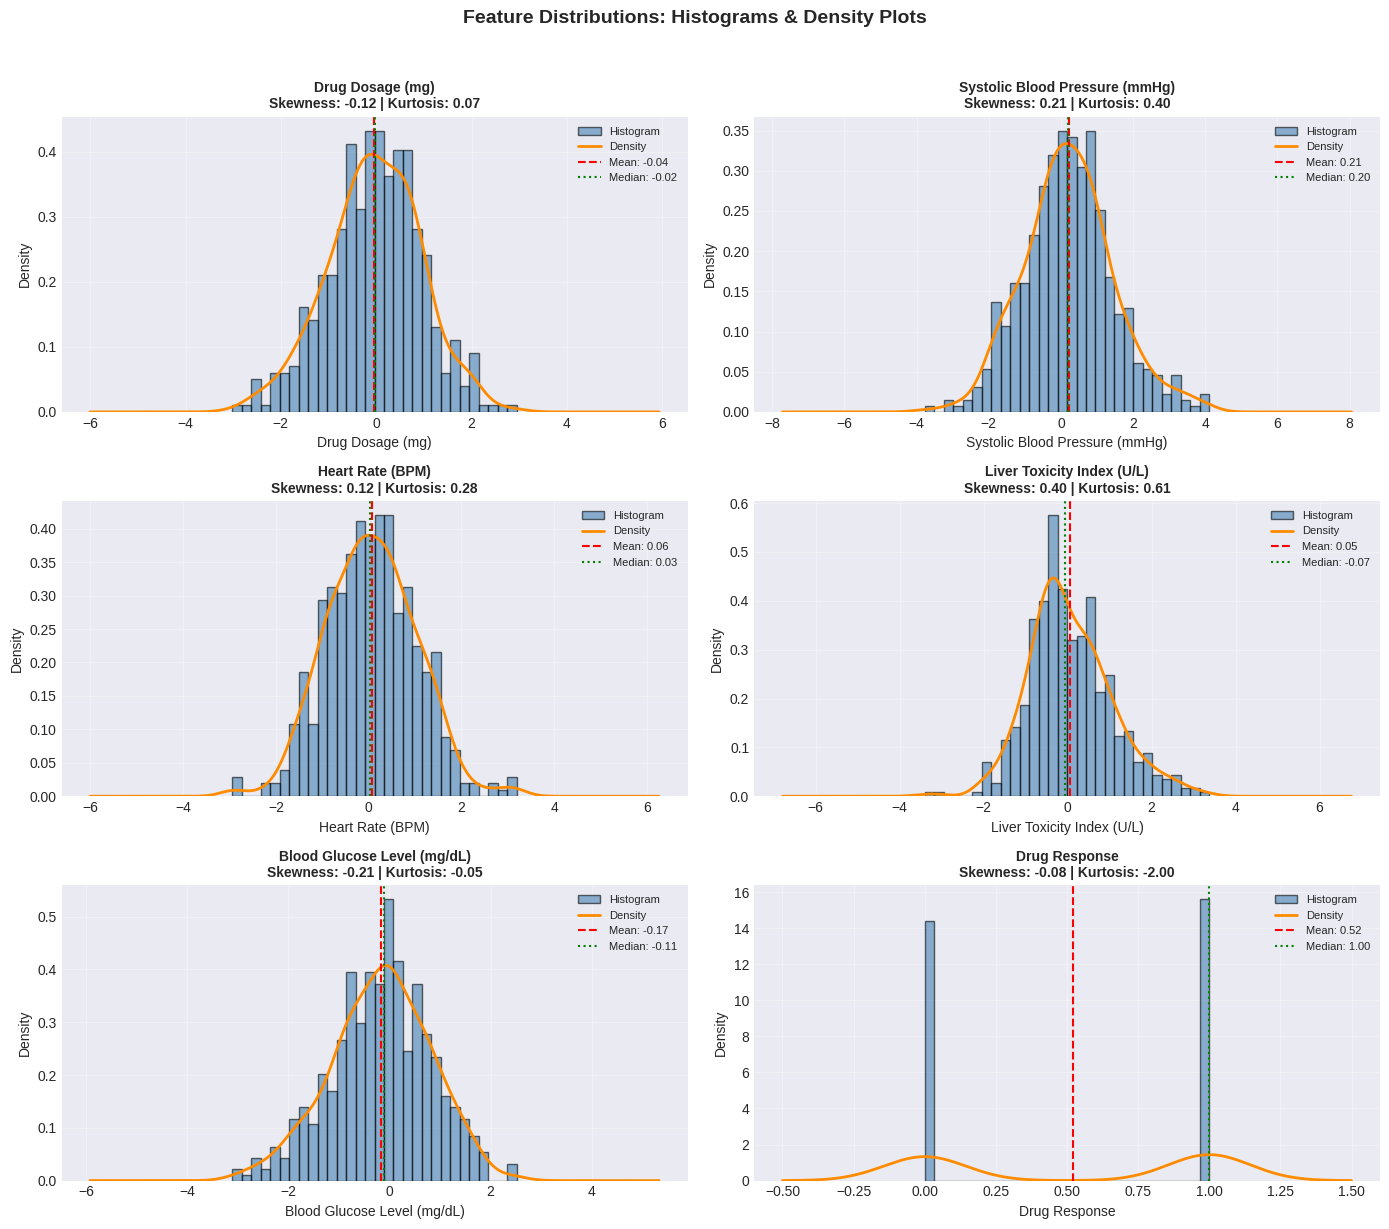

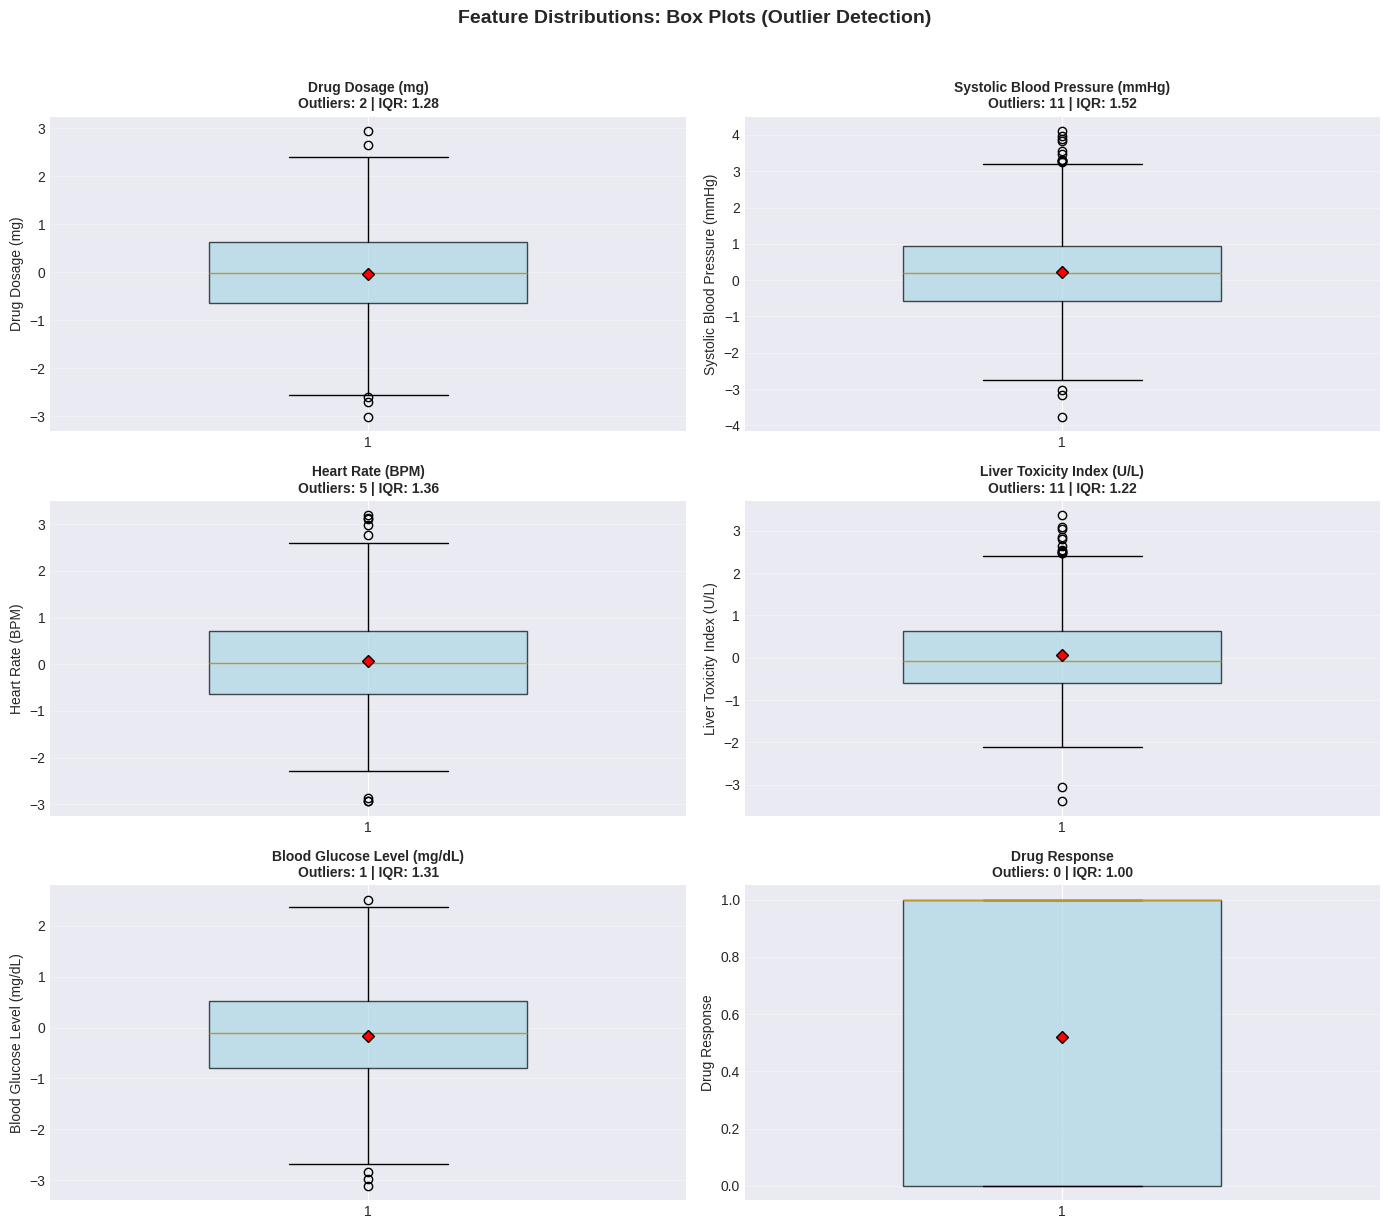

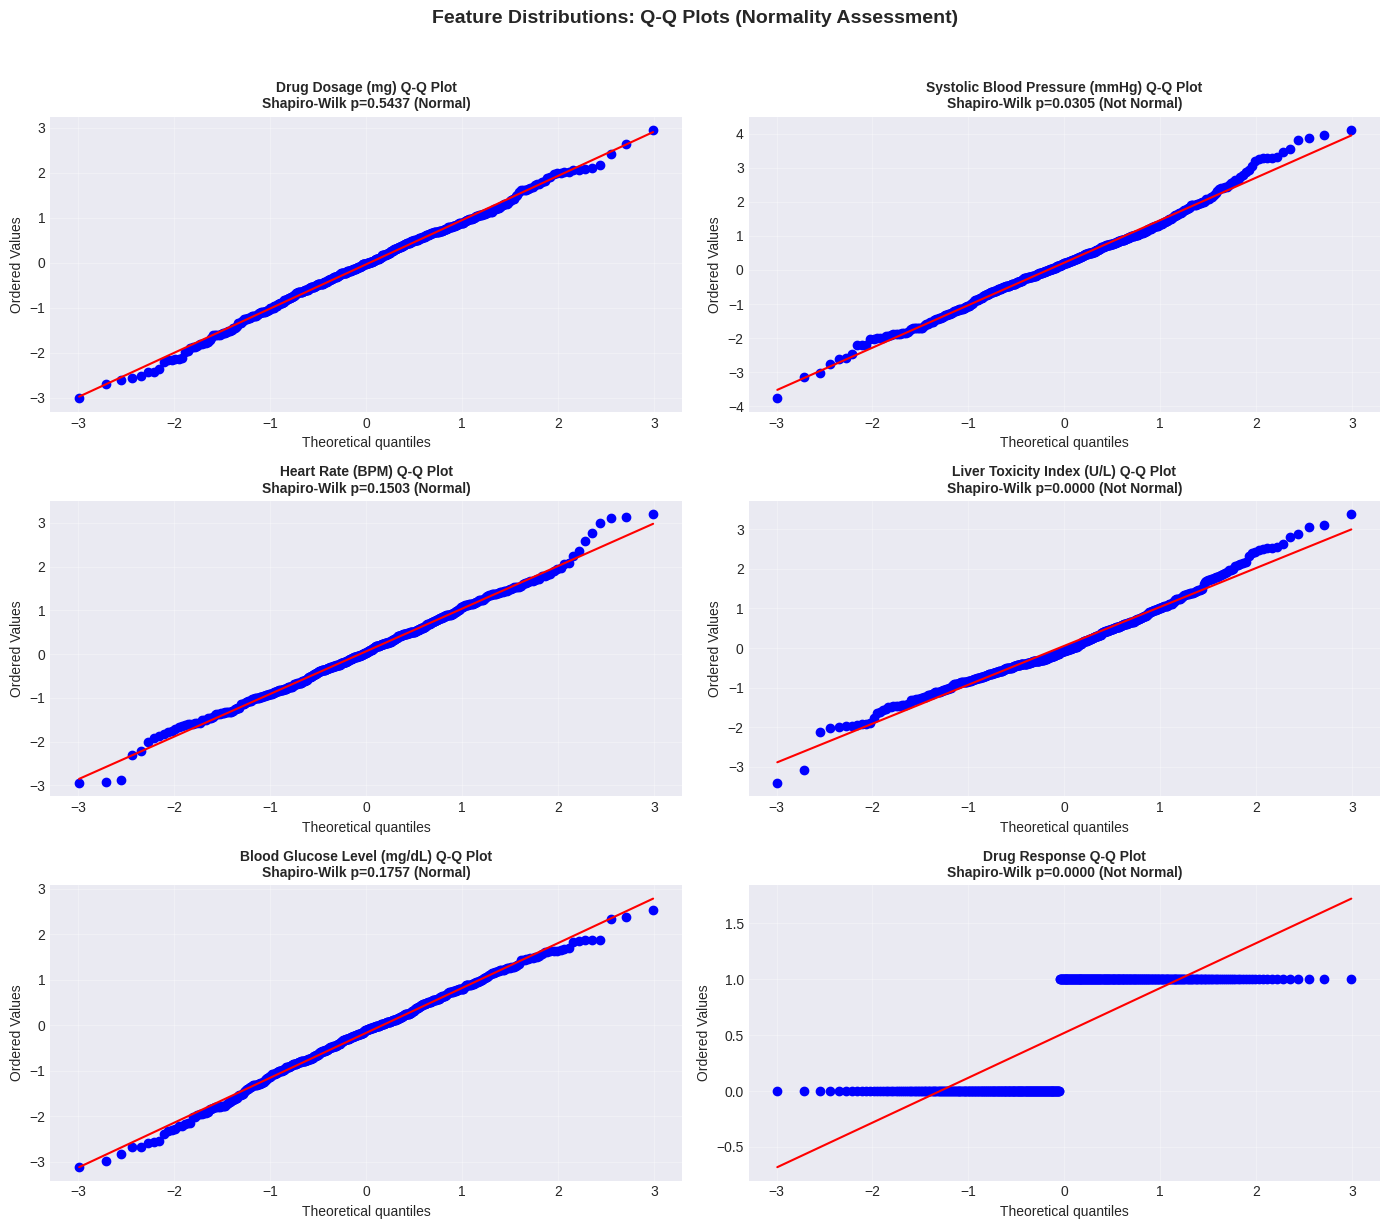


📊 DISTRIBUTION SUMMARY STATISTICS
------------------------------------------------------------
                                 Mean  Median  Std Dev  Skewness  Kurtosis  \
Drug Dosage (mg)               -0.038  -0.019    0.980    -0.124     0.073   
Systolic Blood Pressure (mmHg)  0.215   0.202    1.248     0.215     0.396   
Heart Rate (BPM)                0.063   0.028    0.972     0.120     0.276   
Liver Toxicity Index (U/L)      0.054  -0.066    0.986     0.400     0.614   
Blood Glucose Level (mg/dL)    -0.172  -0.108    0.984    -0.210    -0.053   
Drug Response                   0.520   1.000    0.500    -0.080    -2.002   

                                  Min    25%    75%    Max    IQR  
Drug Dosage (mg)               -3.020 -0.642  0.641  2.949  1.283  
Systolic Blood Pressure (mmHg) -3.774 -0.565  0.951  4.112  1.517  
Heart Rate (BPM)               -2.940 -0.648  0.711  3.193  1.359  
Liver Toxicity Index (U/L)     -3.401 -0.586  0.634  3.373  1.220  
Blood Glucose Lev

In [55]:
#Phase 4: Univariate Analysis (One Variable at a Time)

# ============================================
# TASK 2: FEATURE DISTRIBUTIONS
# ============================================

def plot_feature_distributions(df, max_features=20):
    """
    Create comprehensive distribution plots for numerical features.
    Includes: Histograms, Box Plots, Density Plots, and Q-Q Plots.
    """

    # Select numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = min(len(numerical_cols), max_features)
    numerical_cols = numerical_cols[:n_cols]

    if len(numerical_cols) == 0:
        print("No numerical columns found in dataset.")
        return

    print(f"\n Creating distribution plots for {len(numerical_cols)} numerical features...")

    # Calculate layout
    n_rows = (n_cols + 1) // 2

    # ========== FIGURE 1: HISTOGRAMS + DENSITY PLOTS ==========
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else []

    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            ax = axes[idx]

            # Histogram
            df[col].hist(bins=30, alpha=0.6, color='steelblue', edgecolor='black',
                        density=True, ax=ax, label='Histogram')

            # Density Plot (KDE)
            df[col].dropna().plot(kind='kde', ax=ax, color='darkorange', # Fixed kde argument
                                 linewidth=2, label='Density')

            # Add mean and median lines
            mean_val = df[col].mean()
            median_val = df[col].median()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
                      label=f'Mean: {mean_val:.2f}')
            ax.axvline(median_val, color='green', linestyle=':', linewidth=1.5,
                      label=f'Median: {median_val:.2f}')

            # Styling
            ax.set_title(f'{col}\nSkewness: {df[col].skew():.2f} | Kurtosis: {df[col].kurtosis():.2f}',
                        fontsize=10, fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Density')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Feature Distributions: Histograms & Density Plots',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ========== FIGURE 2: BOX PLOTS (Outlier Detection) ==========
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else []

    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            ax = axes[idx]

            # Box plot with swarm overlay (sample if data is large)
            sample_data = df[col].dropna()
            if len(sample_data) > 1000:
                sample_data = sample_data.sample(1000, random_state=42)

            bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                           widths=0.5, showmeans=True,
                           meanprops={'marker': 'D', 'markerfacecolor': 'red',
                                     'markeredgecolor': 'black'})

            # Color the box
            bp['boxes'][0].set_facecolor('lightblue')
            bp['boxes'][0].set_alpha(0.7)

            # Add swarm plot for small datasets
            if len(sample_data) <= 100:
                sns.swarmplot(y=df[col].dropna(), ax=ax, color='darkblue',
                             alpha=0.5, size=3)

            # Styling
            ax.set_title(f'{col}\nOutliers: {len(df[df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))])} | '
                        f'IQR: {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}',
                        fontsize=10, fontweight='bold')
            ax.set_ylabel(col)
            ax.grid(True, alpha=0.3, axis='y')

    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Feature Distributions: Box Plots (Outlier Detection)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ========== FIGURE 3: Q-Q PLOTS (Normality Check) ==========
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else []

    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            ax = axes[idx]

            # Q-Q plot
            stats.probplot(df[col].dropna(), dist="norm", plot=ax)

            # Shapiro-Wilk test for normality
            if len(df[col].dropna()) <= 5000:
                statistic, p_value = stats.shapiro(df[col].dropna()[:5000])
                normality = "Normal" if p_value > 0.05 else "Not Normal"
                ax.set_title(f'{col} Q-Q Plot\nShapiro-Wilk p={p_value:.4f} ({normality})',
                            fontsize=10, fontweight='bold')
            else:
                ax.set_title(f'{col} Q-Q Plot', fontsize=10, fontweight='bold')

            ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Feature Distributions: Q-Q Plots (Normality Assessment)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ========== SUMMARY STATISTICS ==========
    print("\n📊 DISTRIBUTION SUMMARY STATISTICS")
    print("-"*60)
    dist_stats = pd.DataFrame({
        'Mean': df[numerical_cols].mean(),
        'Median': df[numerical_cols].median(),
        'Std Dev': df[numerical_cols].std(),
        'Skewness': df[numerical_cols].skew(),
        'Kurtosis': df[numerical_cols].kurtosis(),
        'Min': df[numerical_cols].min(),
        '25%': df[numerical_cols].quantile(0.25),
        '75%': df[numerical_cols].quantile(0.75),
        'Max': df[numerical_cols].max(),
        'IQR': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)
    }).round(3)
    print(dist_stats)

# Execute the distribution plots
plot_feature_distributions(df)


 Analyzing correlations for 6 numerical features...


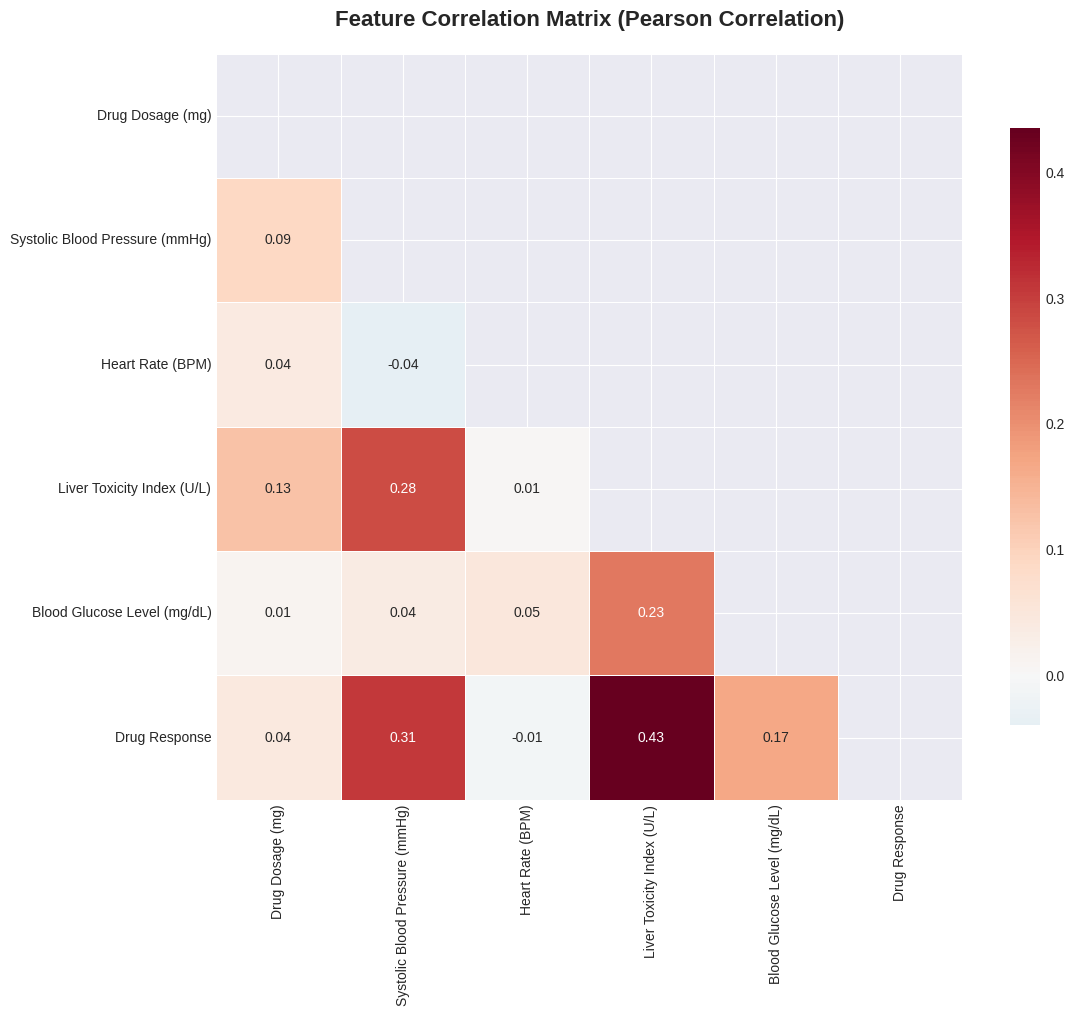


 Creating pairplot for 5 features...


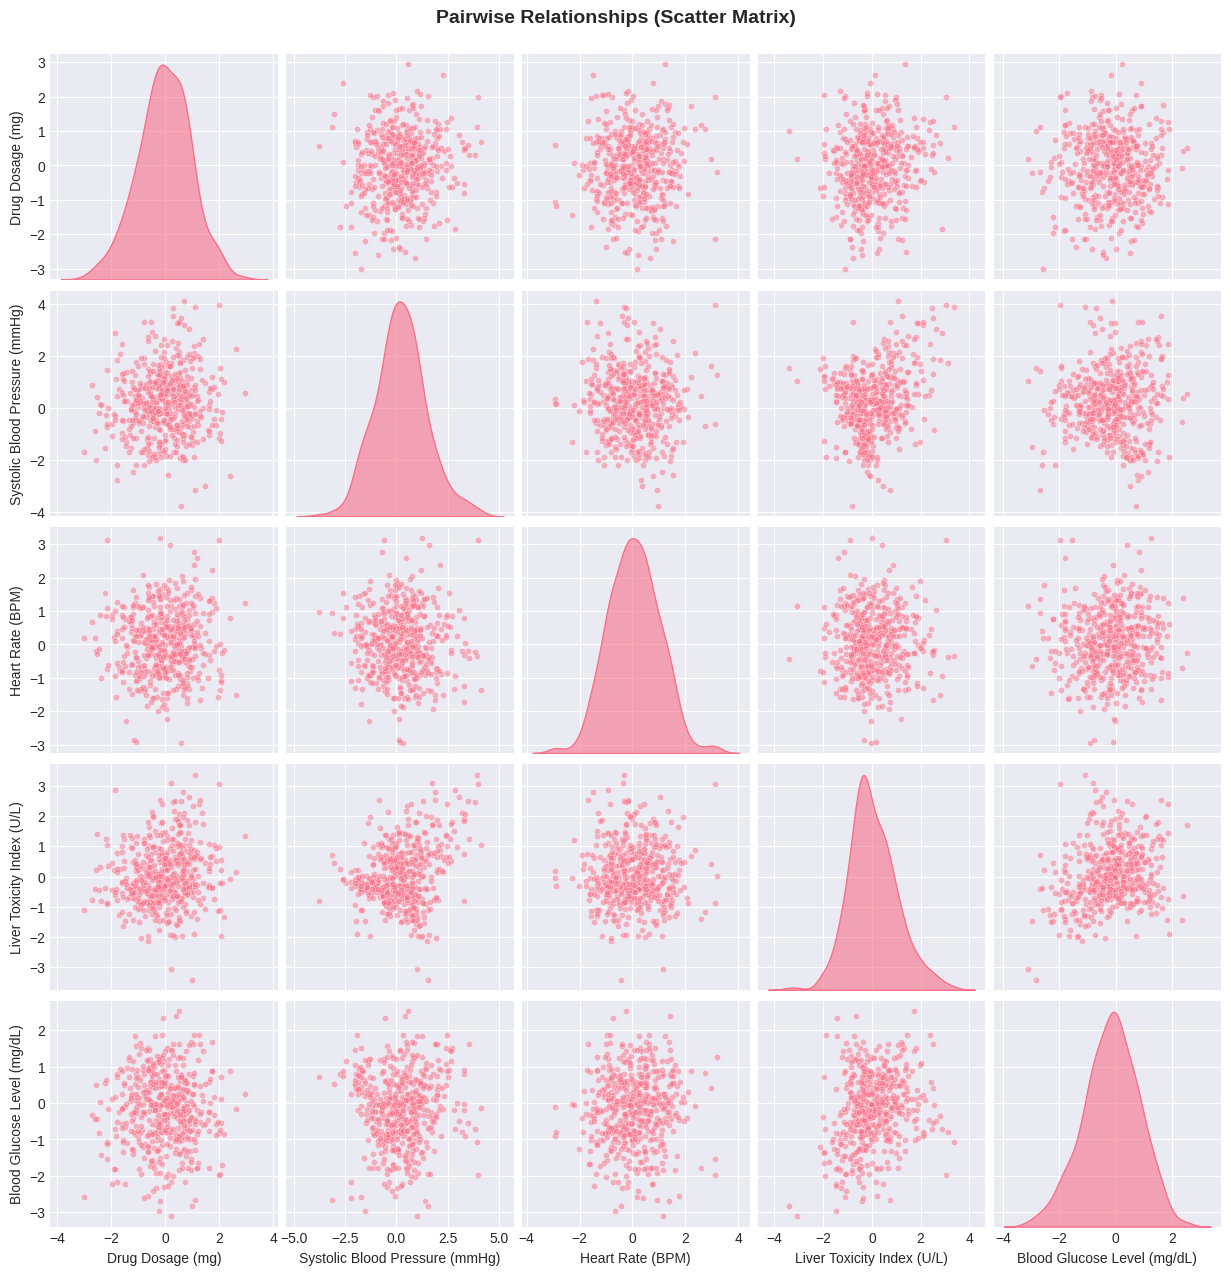

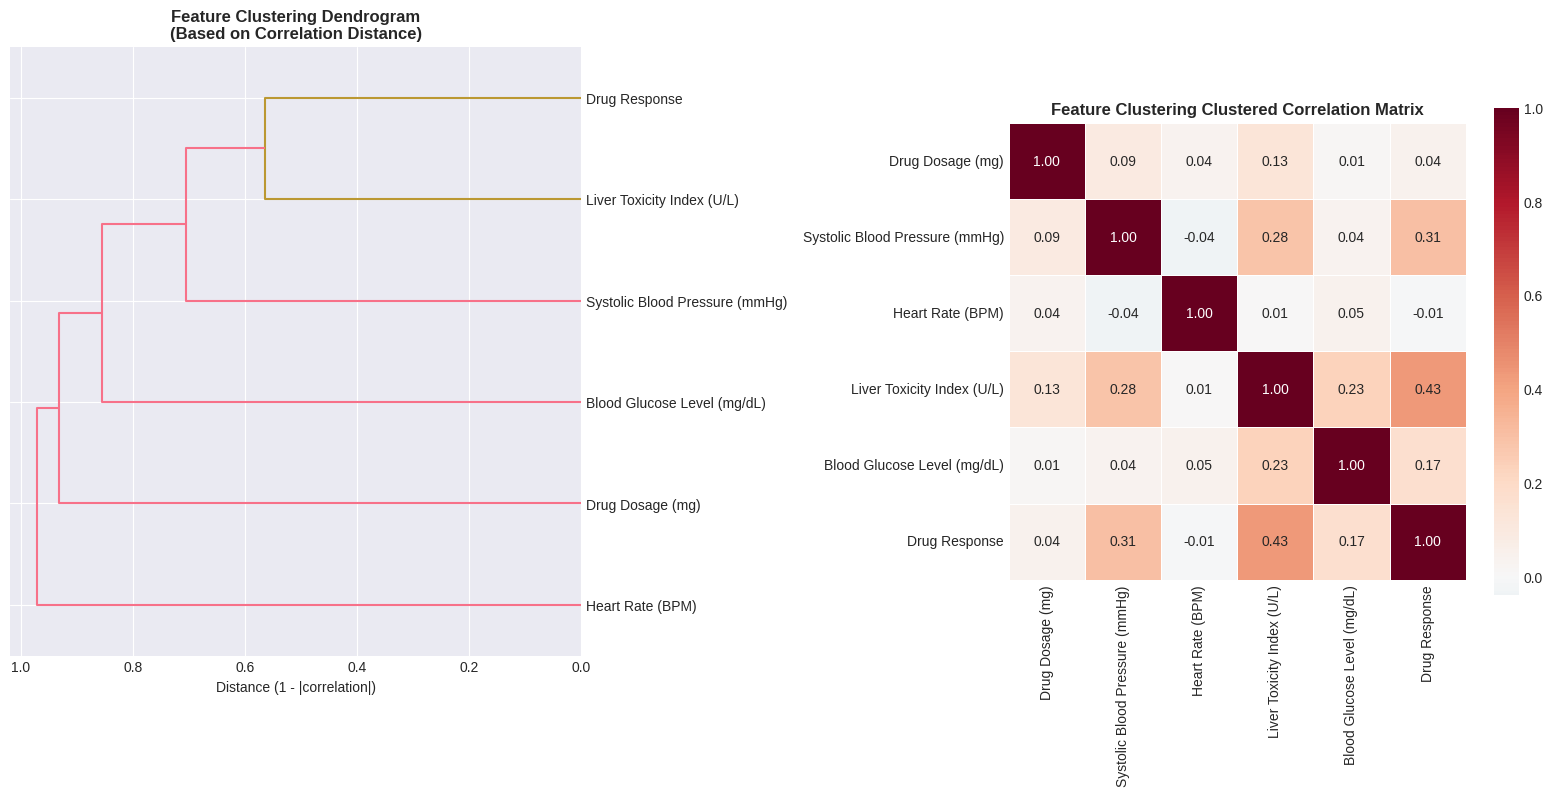


 HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)
------------------------------------------------------------
No highly correlated feature pairs found (|r| > 0.7)

 Feature Correlations with Target: 'Drug Response'
--------------------------------------------------


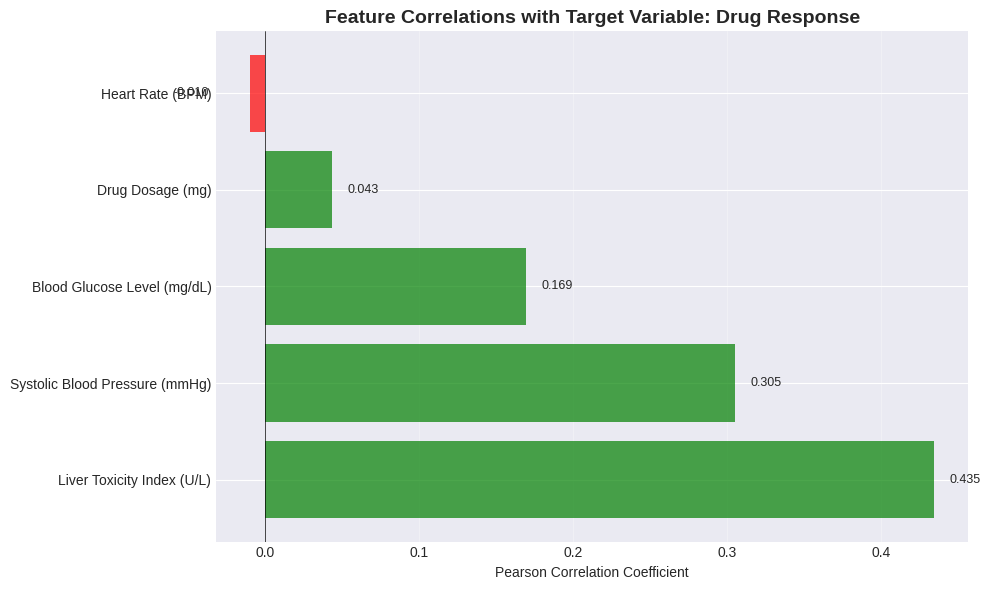


Top 5 Positive Correlations:
Liver Toxicity Index (U/L)        0.434722
Systolic Blood Pressure (mmHg)    0.305226
Blood Glucose Level (mg/dL)       0.169342
Drug Dosage (mg)                  0.043457
Heart Rate (BPM)                 -0.009715

Top 5 Negative Correlations:
Liver Toxicity Index (U/L)        0.434722
Systolic Blood Pressure (mmHg)    0.305226
Blood Glucose Level (mg/dL)       0.169342
Drug Dosage (mg)                  0.043457
Heart Rate (BPM)                 -0.009715


In [56]:
#Phase 5: Bivariate Analysis (Relationships)
# ============================================
# TASK 3: FEATURE CORRELATIONS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

def _plot_correlation_heatmap(corr_matrix, title="Feature Correlation Matrix (Pearson Correlation)", figsize=(12, 10)):
    """Plots a standard correlation heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix,
                mask=mask,
                annot=True,
                fmt='.2f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                ax=ax)
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

def _plot_pairplot(df, numerical_cols, n_features=5, title="Pairwise Relationships (Scatter Matrix)"):
    """Plots a pairplot for a subset of numerical features."""
    selected_cols = numerical_cols[:min(n_features, len(numerical_cols))]
    if len(selected_cols) == 0:
        print("Not enough numerical features for a pairplot.")
        return
    print(f"\n Creating pairplot for {len(selected_cols)} features...")
    g = sns.pairplot(df[selected_cols],
                    diag_kind='kde',
                    plot_kws={'alpha': 0.5, 's': 20},
                    diag_kws={'fill': True, 'alpha': 0.6})
    g.fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.show()

def _plot_clustered_correlation(corr_matrix, title_prefix="Feature Clustering", figsize=(16, 8)):
    """Plots a dendrogram and a clustered heatmap."""
    if corr_matrix.shape[0] < 2:
        print("Not enough features for clustered correlation plot.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    distance_matrix = 1 - abs(corr_matrix)
    # Ensure distance_matrix is symmetric and has no nans before squareform
    distance_matrix = distance_matrix.fillna(0)
    np.fill_diagonal(distance_matrix.values, 0) # Diagonal should be 0 distance

    # Check if squareform input is valid (condensed distance matrix)
    if (distance_matrix.shape[0] * (distance_matrix.shape[0] - 1) / 2) != squareform(distance_matrix).shape[0]:
        # If it's a full square matrix, extract upper triangle for squareform
        upper_triangle_dist = distance_matrix.where(np.triu(np.ones(distance_matrix.shape), k=1).astype(bool)).stack().values
        linkage_matrix = linkage(upper_triangle_dist, method='average')
    else:
        linkage_matrix = linkage(squareform(distance_matrix), method='average')

    dendrogram(linkage_matrix,
              labels=corr_matrix.columns,
              ax=ax1,
              orientation='left',
              leaf_font_size=10)
    ax1.set_title(f'{title_prefix} Dendrogram\n(Based on Correlation Distance)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Distance (1 - |correlation|)')

    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax2)
    ax2.set_title(f'{title_prefix} Clustered Correlation Matrix', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

def _report_highly_correlated_pairs(corr_matrix, threshold=0.7):
    """Identifies and prints highly correlated feature pairs."""
    print("\n HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)")
    print("-"*60)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = []
    for col in upper_triangle.columns:
        high_corr = upper_triangle[col][abs(upper_triangle[col]) > threshold]
        for idx, corr_value in high_corr.items():
            if not pd.isna(corr_value):
                high_corr_pairs.append({'Feature 1': col, 'Feature 2': idx, 'Correlation': corr_value})

    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
        print(high_corr_df.to_string(index=False))
        print("\n")
    else:
        print(f"No highly correlated feature pairs found (|r| > {threshold})")

def _plot_target_correlation(corr_matrix, target_col, title_prefix="Feature Correlations with Target", figsize=(10, 6)):
    """Plots correlations with a specified target variable."""
    print(f"\n {title_prefix}: '{target_col}'")
    print("-"*50)

    target_corr = corr_matrix[target_col].drop(target_col, errors='ignore').sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['green' if x > 0 else 'red' for x in target_corr.values]
    bars = ax.barh(target_corr.index, target_corr.values, color=colors, alpha=0.7)

    for bar, val in zip(bars, target_corr.values):
        ax.text(val + (0.01 if val >= 0 else -0.05),
               bar.get_y() + bar.get_height()/2,
               f'{val:.3f}',
               va='center', fontsize=9)

    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Pearson Correlation Coefficient')
    ax.set_title(f'{title_prefix} Variable: {target_col}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print("\nTop 5 Positive Correlations:")
    print(target_corr.head().to_string())
    print("\nTop 5 Negative Correlations:")
    print(target_corr.tail().to_string())

# Data Visualization
#   1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
#   2. Visualize class distributions to gauge dataset balance or imbalance.
def analyze_correlations(df, target_col=None, max_pairplot_features=5, high_corr_threshold=0.7):
    """
    Comprehensive correlation analysis with multiple visualization methods.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_col (str, optional): Name of the target column for correlation with features.
                                    Defaults to None. If 'Drug Response' exists and target_col is None,
                                    'Drug Response' will be used as default target.
        max_pairplot_features (int): Maximum number of features to include in the pairplot.
        high_corr_threshold (float): Absolute correlation threshold to report highly correlated pairs.

    Returns:
        pd.DataFrame: The calculated correlation matrix.
    """

    numerical_cols = df.select_dtypes(include=[np.number]).columns

    if len(numerical_cols) < 2:
        print("Need at least 2 numerical columns for correlation analysis.")
        return

    print(f"\n Analyzing correlations for {len(numerical_cols)} numerical features...")

    corr_matrix = df[numerical_cols].corr()

    # FIGURE 1: CORRELATION HEATMAP
    _plot_correlation_heatmap(corr_matrix)

    # FIGURE 2: PAIRPLOT (Scatter Matrix)
    _plot_pairplot(df, numerical_cols, n_features=max_pairplot_features)

    # FIGURE 3: CLUSTERED HEATMAP
    _plot_clustered_correlation(corr_matrix)

    # HIGHLY CORRELATED PAIRS
    _report_highly_correlated_pairs(corr_matrix, threshold=high_corr_threshold)

    # CORRELATION WITH TARGET
    effective_target_col = target_col
    if effective_target_col is None and 'Drug Response' in numerical_cols:
        effective_target_col = 'Drug Response'

    if effective_target_col and effective_target_col in numerical_cols:
        _plot_target_correlation(corr_matrix, effective_target_col)
    elif effective_target_col:
        print(f"\nWarning: Target column '{effective_target_col}' not found in numerical features or DataFrame.")

    return corr_matrix

# Execute correlation analysis
correlation_matrix = analyze_correlations(df, target_col='Drug Response')

In [57]:
#SVM CLASSIFIER IMPLEMENTATION

# ============================================
# STEP 2: SVM CLASSIFIER IMPLEMENTATION
# ============================================

class SVMClassifier:
    """
    A wrapper class for SVM implementation with scikit-learn.
    Provides easy-to-use methods for training and evaluation.
    """

    def __init__(self, kernel='rbf', C=1.0, gamma='scale', random_state=42):
        """
        Initialize SVM classifier.

        Parameters:
        -----------
        kernel : str
            Kernel type: 'linear', 'poly', 'rbf', 'sigmoid'
        C : float
            Regularization parameter
        gamma : str or float
            Kernel coefficient for 'rbf', 'poly', 'sigmoid'
        random_state : int
            Random seed for reproducibility
        """
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.random_state = random_state

        # Initialize the SVM model
        self.model = svm.SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            probability=True,  # Enable probability estimates for ROC curve
            random_state=random_state
        )

        self.is_fitted = False
        self.training_time = None

    def train(self, X_train, y_train):
        """
        Train the SVM model on the training data.

        Parameters:
        -----------
        X_train : array-like
            Training features
        y_train : array-like
            Training labels
        """
        import time

        print(f"\n🎯 TRAINING SVM CLASSIFIER")
        print("-"*50)
        print(f"Kernel: {self.kernel}")
        print(f"C (Regularization): {self.C}")
        print(f"Gamma: {self.gamma}")
        print(f"Training samples: {X_train.shape[0]}")

        # Train the model
        start_time = time.time()
        self.model.fit(X_train, y_train)
        self.training_time = time.time() - start_time

        self.is_fitted = True

        print(f" Training complete in {self.training_time:.3f} seconds")

        # Get number of support vectors
        n_support_vectors = self.model.n_support_
        print(f" Support Vectors: {sum(n_support_vectors)} total")
        if len(n_support_vectors) > 1:
            for i, n in enumerate(n_support_vectors):
                print(f"   Class {i}: {n} support vectors")

        return self

    def predict(self, X_test):
        """
        Make predictions on test data.

        Parameters:
        -----------
        X_test : array-like
            Testing features

        Returns:
        --------
        predictions : array
            Predicted labels
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained before prediction!")

        return self.model.predict(X_test)

    def predict_proba(self, X_test):
        """
        Get probability estimates for predictions.

        Parameters:
        -----------
        X_test : array-like
            Testing features

        Returns:
        --------
        probabilities : array
            Probability estimates for each class
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained before prediction!")

        return self.model.predict_proba(X_test)

In [58]:
# STEP 3: COMPREHENSIVE MODEL EVALUATION
# ============================================

def evaluate_svm_model(model, X_test, y_test, label_encoder=None):
    """
    Comprehensive evaluation of SVM model performance.

    Parameters:
    -----------
    model : SVMClassifier
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True labels
    label_encoder : LabelEncoder
        Label encoder for class names

    Returns:
    --------
    metrics : dict
        Dictionary containing all evaluation metrics
    """

    print("\n" + "="*70)
    print("📊 MODEL EVALUATION RESULTS")
    print("="*70)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # For binary classification
    if len(np.unique(y_test)) == 2:
        precision_binary = precision_score(y_test, y_pred)
        recall_binary = recall_score(y_test, y_pred)
        f1_binary = f1_score(y_test, y_pred)

    # Display metrics
    print("\n📈 PERFORMANCE METRICS:")
    print("-"*50)
    print(f"✓ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✓ Precision: {precision:.4f}")
    print(f"✓ Recall:    {recall:.4f}")
    print(f"✓ F1-Score:  {f1:.4f}")

    if len(np.unique(y_test)) == 2:
        print(f"\n   Binary Metrics:")
        print(f"   - Precision: {precision_binary:.4f}")
        print(f"   - Recall:    {recall_binary:.4f}")
        print(f"   - F1-Score:  {f1_binary:.4f}")

    # Detailed Classification Report
    print("\n📋 DETAILED CLASSIFICATION REPORT:")
    print("-"*50)

    if label_encoder:
        target_names = [str(c) for c in label_encoder.classes_]
    else:
        target_names = [f'Class {i}' for i in np.unique(y_test)]

    print(classification_report(y_test, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualization: Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Confusion Matrix Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                ax=axes[0])
    axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Plot 2: Normalized Confusion Matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=target_names,
                yticklabels=target_names,
                ax=axes[1])
    axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    # ROC Curve (for binary classification)
    if len(np.unique(y_test)) == 2:
        plot_roc_curve(model, X_test, y_test)

    # Cross-validation score
    print("\n🔄 CROSS-VALIDATION (5-fold):")
    print("-"*50)
    cv_scores = cross_val_score(model.model, X_test, y_test, cv=5)
    print(f"CV Scores: {cv_scores}")
    print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    # Store metrics
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    if len(np.unique(y_test)) == 2:
        metrics.update({
            'precision_binary': precision_binary,
            'recall_binary': recall_binary,
            'f1_binary': f1_binary
        })

    return metrics, y_pred


def plot_roc_curve(model, X_test, y_test):
    """
    Plot ROC curve for binary classification.

    Parameters:
    -----------
    model : SVMClassifier
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True labels
    """

    # Get probability estimates
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve',
              fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\n📊 ROC AUC Score: {roc_auc:.4f}")


 Creating synthetic dataset for demonstration...
 Training SVM model...

 GENERATING COMPREHENSIVE SVM VISUALIZATIONS

1️ Visualizing Decision Boundary...

2️ Analyzing Support Vectors...

3️ Creating Classification Dashboard...


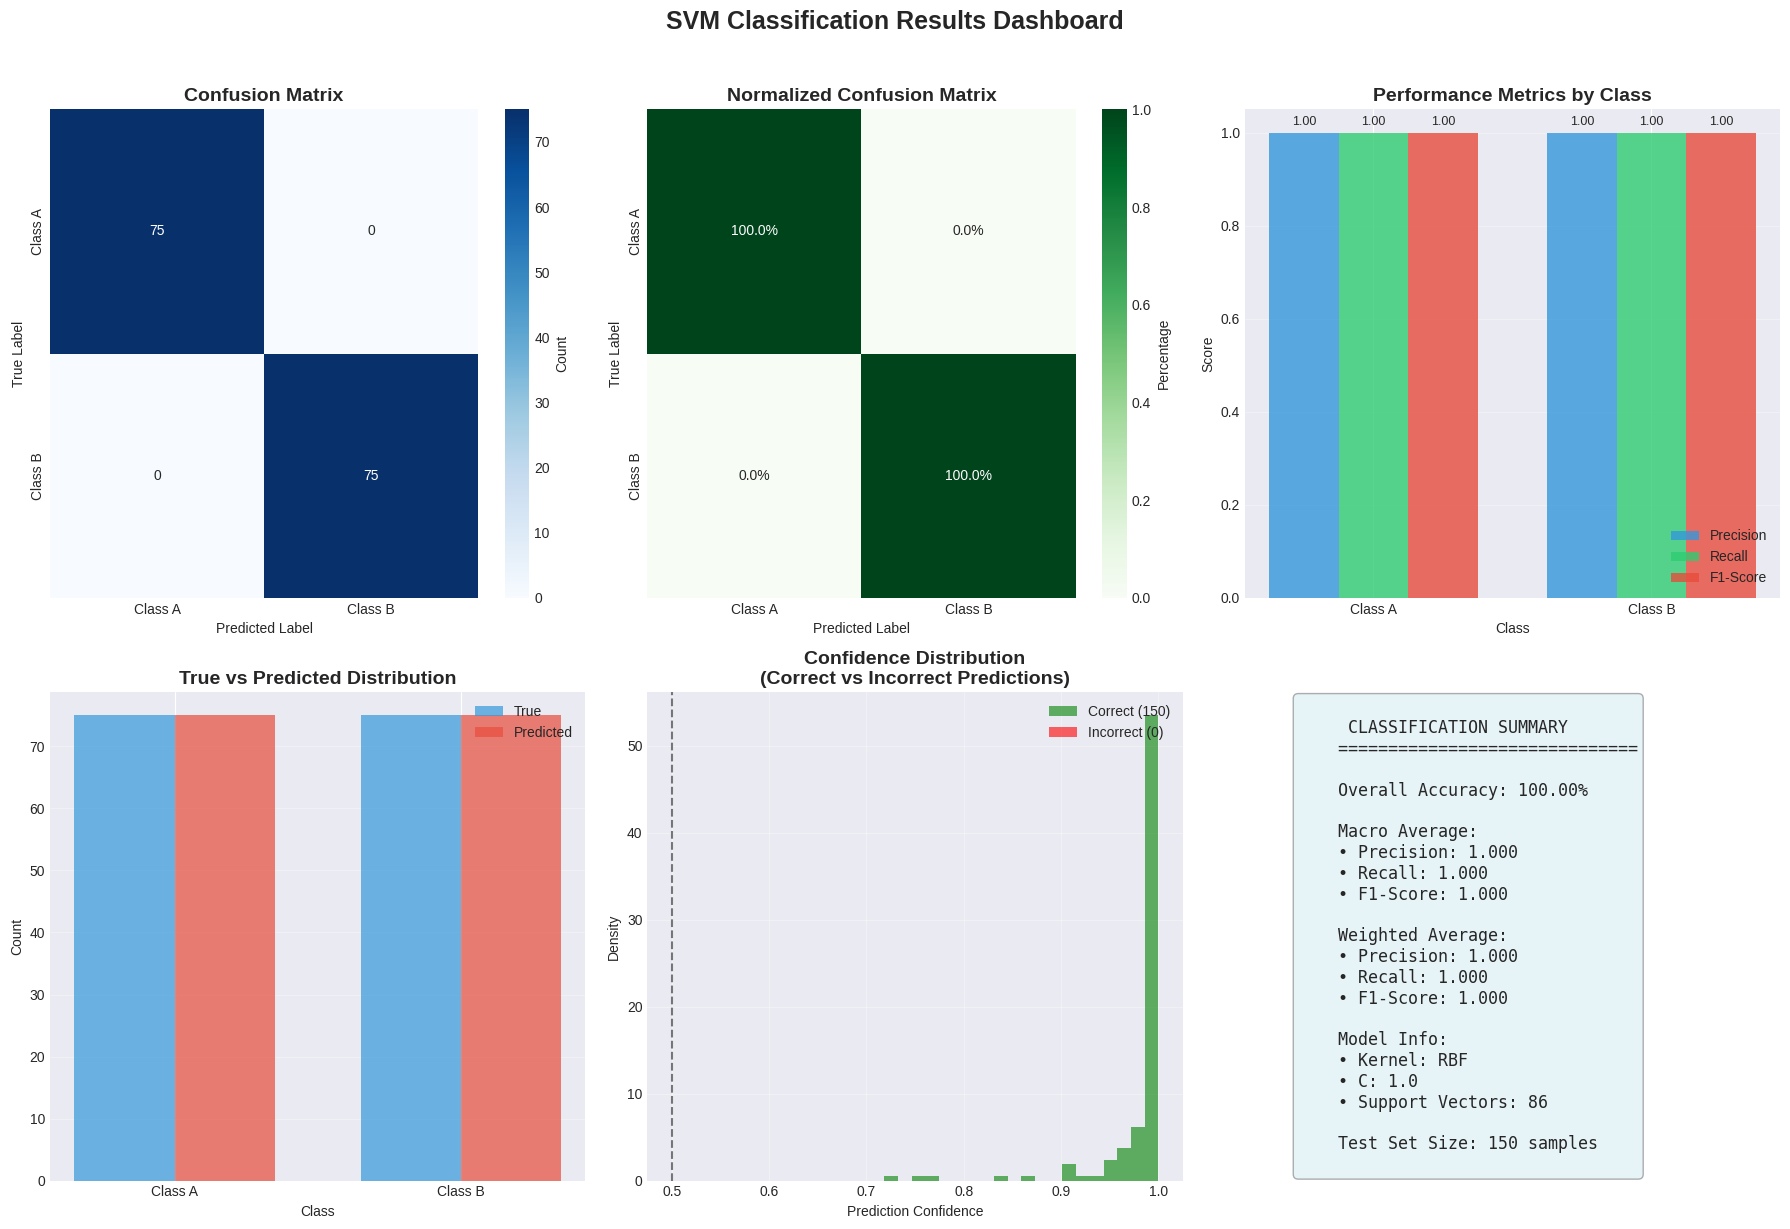


 Analyzing Test Predictions in Detail...


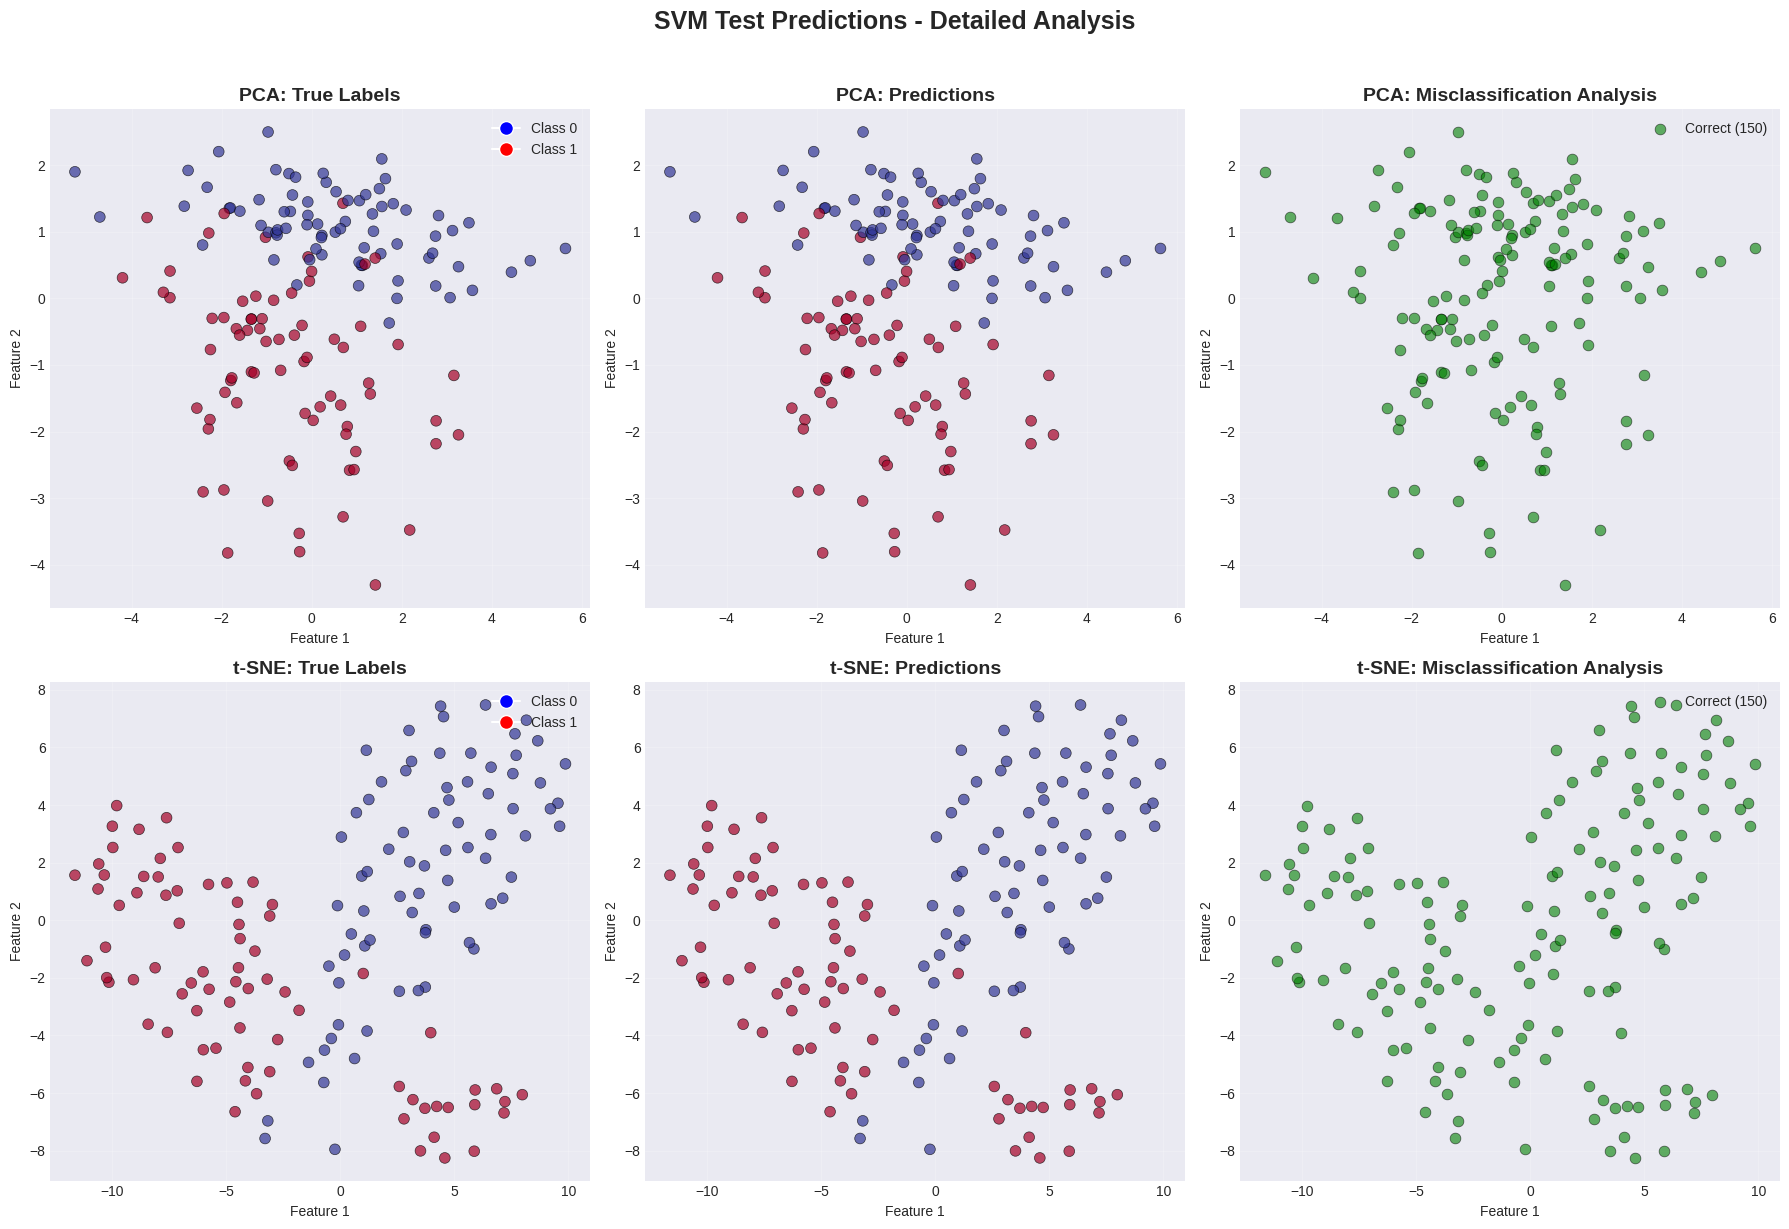


 Analyzing Prediction Confidence...


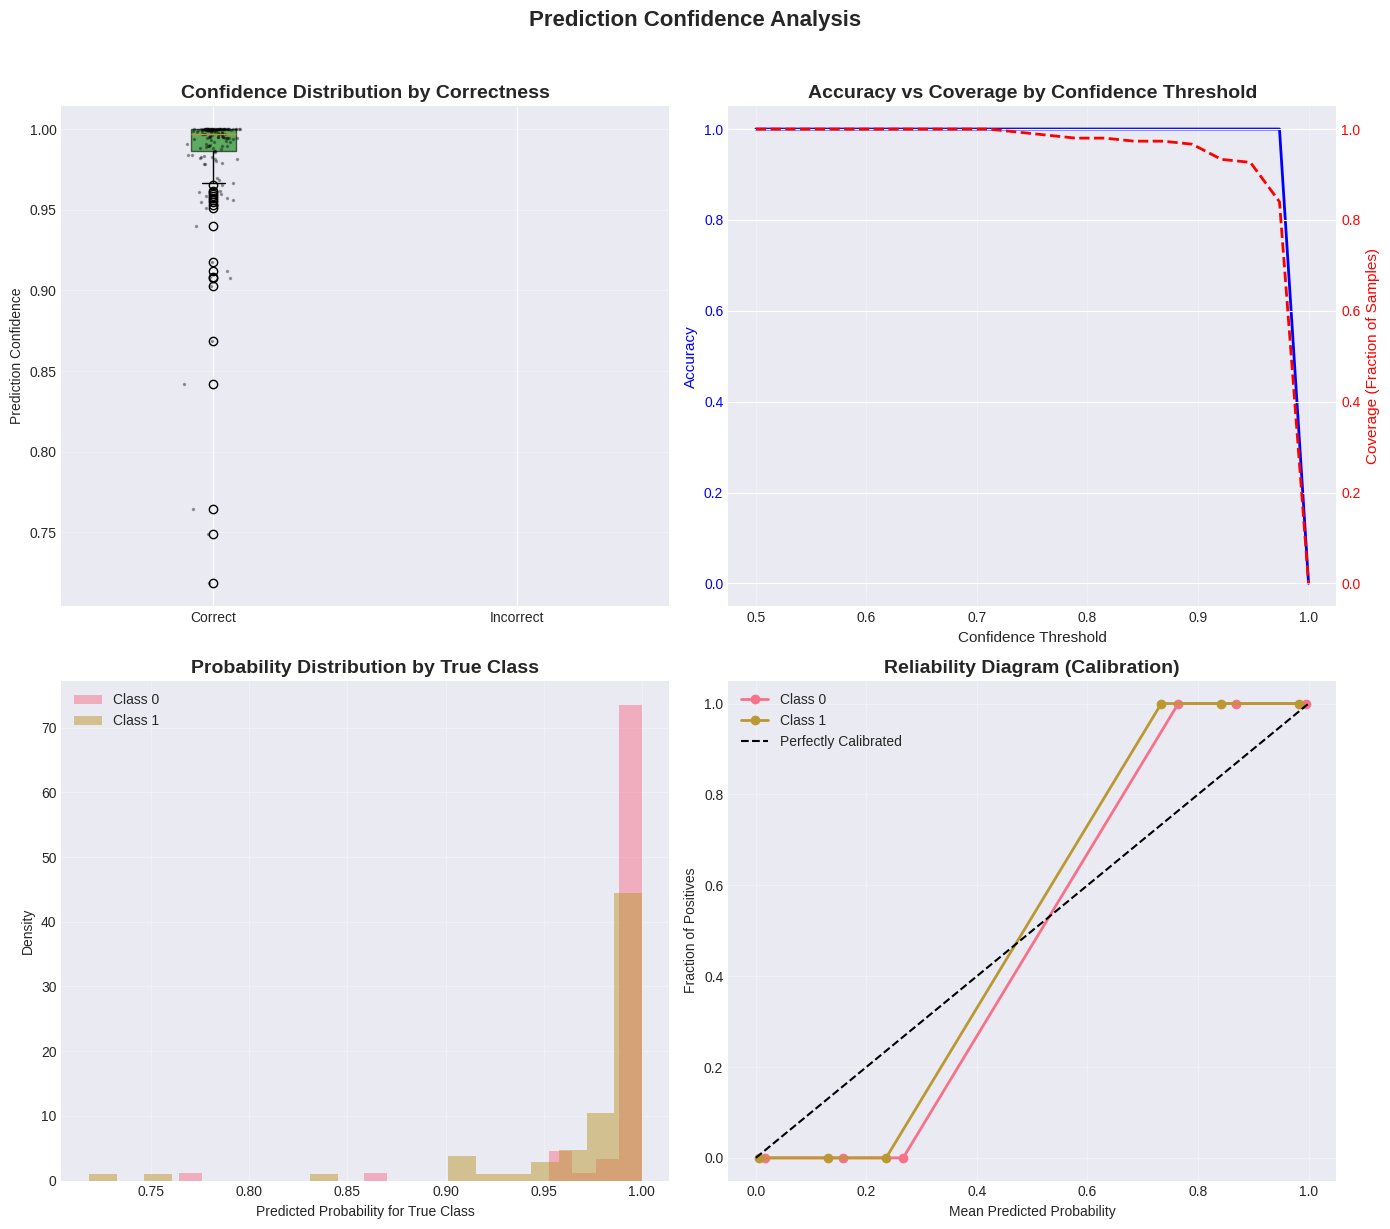


 Creating Interactive Plot...
   Skipping interactive visualization

 ALL VISUALIZATIONS COMPLETE!

 SVM Visualization Module Loaded Successfully!

 QUICK USAGE:
   visualize_svm_on_test_data(your_trained_model, X_test_scaled, y_test)

 Available Visualization Functions:
   1. visualize_decision_boundary() - Plot decision regions
   2. visualize_support_vectors() - Analyze support vectors
   3. visualize_classification_results() - Comprehensive dashboard
   4. visualize_test_predictions_detail() - PCA/t-SNE analysis
   5. visualize_confidence_analysis() - Confidence scores
   6. visualize_all_svm_results() - Run all visualizations


In [59]:
# ============================================
# 2. CLASSIFICATION RESULTS DASHBOARD
# ============================================

def visualize_classification_results(model, X_test, y_test, class_names=None):
    """
    Create comprehensive visualization of classification results.

    Parameters:
    -----------
    model : sklearn.svm.SVC
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True test labels
    class_names : list
        Names of classes
    """

    # Make predictions
    y_pred = model.predict(X_test)

    if class_names is None:
        class_names = [f'Class {i}' for i in np.unique(y_test)]

    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

    # Create comprehensive dashboard
    fig = plt.figure(figsize=(18, 12))

    # 1. Confusion Matrix (top left)
    ax1 = plt.subplot(2, 3, 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    # 2. Normalized Confusion Matrix (top middle)
    ax2 = plt.subplot(2, 3, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax2, cbar_kws={'label': 'Percentage'})
    ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')

    # 3. Metrics Bar Chart (top right)
    ax3 = plt.subplot(2, 3, 3)
    x = np.arange(len(class_names))
    width = 0.25

    bars1 = ax3.bar(x - width, precision, width, label='Precision', color='#3498db', alpha=0.8)
    bars2 = ax3.bar(x, recall, width, label='Recall', color='#2ecc71', alpha=0.8)
    bars3 = ax3.bar(x + width, f1, width, label='F1-Score', color='#e74c3c', alpha=0.8)

    ax3.set_xlabel('Class')
    ax3.set_ylabel('Score')
    ax3.set_title('Performance Metrics by Class', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(class_names)
    ax3.legend(loc='lower right')
    ax3.set_ylim([0, 1.05])
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    # 4. Prediction Distribution (bottom left)
    ax4 = plt.subplot(2, 3, 4)

    # Count predictions
    pred_counts = pd.Series(y_pred).value_counts().sort_index()
    true_counts = pd.Series(y_test).value_counts().sort_index()

    x = np.arange(len(class_names))
    width = 0.35

    bars1 = ax4.bar(x - width/2, true_counts.values, width, label='True',
                   color='#3498db', alpha=0.7)
    bars2 = ax4.bar(x + width/2, pred_counts.values, width, label='Predicted',
                   color='#e74c3c', alpha=0.7)

    ax4.set_xlabel('Class')
    ax4.set_ylabel('Count')
    ax4.set_title('True vs Predicted Distribution', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(class_names)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # 5. Confidence Distribution (bottom middle)
    ax5 = plt.subplot(2, 3, 5)

    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)
        max_proba = np.max(proba, axis=1)

        # Separate by correct/incorrect predictions
        correct = y_pred == y_test
        incorrect = ~correct

        ax5.hist(max_proba[correct], bins=20, alpha=0.6, color='green',
                label=f'Correct ({correct.sum()})', density=True)
        ax5.hist(max_proba[incorrect], bins=20, alpha=0.6, color='red',
                label=f'Incorrect ({incorrect.sum()})', density=True)

        ax5.set_xlabel('Prediction Confidence')
        ax5.set_ylabel('Density')
        ax5.set_title('Confidence Distribution\n(Correct vs Incorrect Predictions)',
                    fontsize=14, fontweight='bold')
        ax5.legend()
        ax5.grid(True, alpha=0.3)

        # Add vertical line at 0.5
        ax5.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

    # 6. Overall Metrics Summary (bottom right)
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')

    # Create summary text
    summary_text = f"""
     CLASSIFICATION SUMMARY
    {'='*30}

    Overall Accuracy: {accuracy:.2%}

    Macro Average:
    • Precision: {np.mean(precision):.3f}
    • Recall: {np.mean(recall):.3f}
    • F1-Score: {np.mean(f1):.3f}

    Weighted Average:
    • Precision: {np.average(precision, weights=support):.3f}
    • Recall: {np.average(recall, weights=support):.3f}
    • F1-Score: {np.average(f1, weights=support):.3f}

    Model Info:
    • Kernel: {model.kernel.upper()}
    • C: {model.C}
    • Support Vectors: {len(model.support_vectors_)}

    Test Set Size: {len(y_test):,} samples
    """

    ax6.text(0.1, 0.5, summary_text, transform=ax6.transAxes,
            fontsize=12, verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

    plt.suptitle('SVM Classification Results Dashboard',
                fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return fig

    # ============================================
# 3. ADVANCED TEST DATA VISUALIZATIONS
# ============================================

def visualize_test_predictions_detail(model, X_test, y_test, feature_names=None):
    """
    Detailed visualization of test predictions with multiple views.

    Parameters:
    -----------
    model : sklearn.svm.SVC
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True test labels
    feature_names : list
        Names of features
    """
    from sklearn.decomposition import PCA # Added import for PCA
    from sklearn.manifold import TSNE # Added import for TSNE

    y_pred = model.predict(X_test)

    # Reduce dimensionality for visualization
    if X_test.shape[1] > 2:
        # Use both PCA and t-SNE for comparison
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_test)

        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(X_test)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Row 1: PCA views
        plot_test_points_with_predictions(X_pca, y_test, y_pred, axes[0, 0],
                                         "PCA: True Labels", show_legend=True)
        plot_test_points_with_predictions(X_pca, y_test, y_pred, axes[0, 1],
                                         "PCA: Predictions", show_predictions=True)
        plot_misclassification_analysis(X_pca, y_test, y_pred, axes[0, 2],
                                       "PCA: Misclassification Analysis")

        # Row 2: t-SNE views
        plot_test_points_with_predictions(X_tsne, y_test, y_pred, axes[1, 0],
                                         "t-SNE: True Labels", show_legend=True)
        plot_test_points_with_predictions(X_tsne, y_test, y_pred, axes[1, 1],
                                         "t-SNE: Predictions", show_predictions=True)
        plot_misclassification_analysis(X_tsne, y_test, y_pred, axes[1, 2],
                                       "t-SNE: Misclassification Analysis")

    else:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        plot_test_points_with_predictions(X_test, y_test, y_pred, axes[0],
                                         "True Labels", show_legend=True)
        plot_test_points_with_predictions(X_test, y_test, y_pred, axes[1],
                                         "Predictions", show_predictions=True)
        plot_misclassification_analysis(X_test, y_test, y_pred, axes[2],
                                       "Misclassification Analysis")

    plt.suptitle('SVM Test Predictions - Detailed Analysis',
                fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return fig


def plot_test_points_with_predictions(X_2d, y_true, y_pred, ax, title,
                                      show_predictions=False, show_legend=False):
    """Helper function to plot test points with true or predicted labels."""

    if show_predictions:
        colors = y_pred
        legend_elements = None
    else:
        colors = y_true
        legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=c, markersize=10, label=f'Class {i}')
                          for i, c in enumerate(['blue', 'red'])]

    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors,
                        cmap='RdYlBu', edgecolors='black',
                        linewidth=0.5, s=60, alpha=0.7)

    ax.set_xlabel('Component 1' if X_2d.shape[1] > 2 else 'Feature 1')
    ax.set_ylabel('Component 2' if X_2d.shape[1] > 2 else 'Feature 2')
    ax.set_title(title, fontsize=14, fontweight='bold')

    if show_legend and legend_elements:
        ax.legend(handles=legend_elements, loc='upper right')

    ax.grid(True, alpha=0.2)


def plot_misclassification_analysis(X_2d, y_true, y_pred, ax, title):
    """Helper function to highlight misclassified points."""

    correct = y_true == y_pred
    incorrect = ~correct

    # Plot correct predictions
    ax.scatter(X_2d[correct, 0], X_2d[correct, 1],
              c='green', marker='o', edgecolors='black',
              linewidth=0.5, s=60, alpha=0.6, label=f'Correct ({correct.sum()})')

    # Highlight incorrect predictions
    if incorrect.any():
        ax.scatter(X_2d[incorrect, 0], X_2d[incorrect, 1],
                  c='red', marker='X', edgecolors='black',
                  linewidth=1.5, s=150, alpha=0.9, label=f'Incorrect ({incorrect.sum()})')

        # Add arrows or annotations for misclassified points
        for i in np.where(incorrect)[0]:
            ax.annotate('', xy=(X_2d[i, 0], X_2d[i, 1]),
                       xytext=(X_2d[i, 0] + 0.5, X_2d[i, 1] + 0.5),
                       arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))

    ax.set_xlabel('Component 1' if X_2d.shape[1] > 2 else 'Feature 1')
    ax.set_ylabel('Component 2' if X_2d.shape[1] > 2 else 'Feature 2')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)


def visualize_confidence_analysis(model, X_test, y_test):
    """
    Analyze prediction confidence on test data.

    Parameters:
    -----------
    model : sklearn.svm.SVC
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True test labels
    """

    if not hasattr(model, 'predict_proba'):
        print("Model does not support probability estimates.")
        return

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. Confidence vs Correctness
    ax1 = axes[0, 0]

    max_proba = np.max(proba, axis=1)
    correct = y_pred == y_test

    # Box plot
    data_to_plot = [max_proba[correct], max_proba[~correct]]
    bp = ax1.boxplot(data_to_plot, labels=['Correct', 'Incorrect'],
                    patch_artist=True)

    for patch, color in zip(bp['boxes'], ['green', 'red']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax1.set_ylabel('Prediction Confidence')
    ax1.set_title('Confidence Distribution by Correctness',
                 fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Add swarm plot overlay
    for i, data in enumerate(data_to_plot):
        y = data
        x = np.random.normal(i+1, 0.04, size=len(y))
        ax1.plot(x, y, 'k.', alpha=0.3, markersize=3)

    # 2. Confidence threshold analysis
    ax2 = axes[0, 1]

    thresholds = np.linspace(0.5, 1.0, 20)
    accuracies = []
    coverages = []

    for thresh in thresholds:
        high_conf_mask = max_proba >= thresh
        if high_conf_mask.sum() > 0:
            acc = accuracy_score(y_test[high_conf_mask], y_pred[high_conf_mask])
            cov = high_conf_mask.mean()
        else:
            acc = 0
            cov = 0
        accuracies.append(acc)
        coverages.append(cov)

    ax2.plot(thresholds, accuracies, 'b-', linewidth=2, label='Accuracy')
    ax2.set_xlabel('Confidence Threshold', fontsize=11)
    ax2.set_ylabel('Accuracy', fontsize=11, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    ax2_twin = ax2.twinx()
    ax2_twin.plot(thresholds, coverages, 'r--', linewidth=2, label='Coverage')
    ax2_twin.set_ylabel('Coverage (Fraction of Samples)', fontsize=11, color='red')
    ax2_twin.tick_params(axis='y', labelcolor='red')

    ax2.set_title('Accuracy vs Coverage by Confidence Threshold',
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # 3. Confidence histogram by class
    ax3 = axes[1, 0]

    for i, class_label in enumerate(np.unique(y_test)):
        mask = y_test == class_label
        class_proba = proba[mask, i]
        ax3.hist(class_proba, bins=20, alpha=0.5, label=f'Class {class_label}',
                density=True)

    ax3.set_xlabel('Predicted Probability for True Class')
    ax3.set_ylabel('Density')
    ax3.set_title('Probability Distribution by True Class',
                 fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Calibration plot (Reliability Diagram)
    ax4 = axes[1, 1]

    from sklearn.calibration import calibration_curve

    for i in range(proba.shape[1]):
        prob_true, prob_pred = calibration_curve(y_test == i, proba[:, i], n_bins=10)
        ax4.plot(prob_pred, prob_true, marker='o', linewidth=2,
                label=f'Class {i}')

    ax4.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    ax4.set_xlabel('Mean Predicted Probability')
    ax4.set_ylabel('Fraction of Positives')
    ax4.set_title('Reliability Diagram (Calibration)',
                 fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Prediction Confidence Analysis',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return fig

    # ============================================
# 4. INTERACTIVE VISUALIZATION (Plotly)
# ============================================

def create_interactive_visualization(model, X_test, y_test, feature_names=None):
    """
    Create interactive visualization using Plotly.

    Parameters:
    -----------
    model : sklearn.svm.SVC
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True test labels
    feature_names : list
        Names of features
    """

    try:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
    except ImportError:
        print("Plotly not installed. Install with: pip install plotly")
        return

    # Reduce to 2D or 3D
    if X_test.shape[1] > 2:
        pca = PCA(n_components=3, random_state=42)
        X_reduced = pca.fit_transform(X_test)
        dims = ['PC1', 'PC2', 'PC3']
    else:
        X_reduced = X_test
        dims = ['Feature 1', 'Feature 2', None]

    y_pred = model.predict(X_test)
    correct = y_pred == y_test

    # Create 3D scatter plot
    fig = go.Figure()

    # Add correct predictions
    fig.add_trace(go.Scatter3d(
        x=X_reduced[correct, 0],
        y=X_reduced[correct, 1],
        z=X_reduced[correct, 2] if X_reduced.shape[1] > 2 else np.zeros(correct.sum()),
        mode='markers',
        marker=dict(
            size=6,
            color=y_test[correct],
            colorscale='RdYlBu',
            opacity=0.7,
            symbol='circle'
        ),
        name='Correct Predictions',
        text=[f'True: {t}<br>Pred: {p}' for t, p in zip(y_test[correct], y_pred[correct])],
        hoverinfo='text'
    ))

    # Add incorrect predictions
    if (~correct).any():
        fig.add_trace(go.Scatter3d(
            x=X_reduced[~correct, 0],
            y=X_reduced[~correct, 1],
            z=X_reduced[~correct, 2] if X_reduced.shape[1] > 2 else np.zeros((~correct).sum()),
            mode='markers',
            marker=dict(
                size=12,
                color='red',
                symbol='x',
                line=dict(width=2, color='black')
            ),
            name='Misclassified',
            text=[f'True: {t}<br>Pred: {p}' for t, p in zip(y_test[~correct], y_pred[~correct])],
            hoverinfo='text'
        ))

    fig.update_layout(
        title=f'SVM Test Predictions (Accuracy: {correct.mean():.2%})',
        scene=dict(
            xaxis_title=dims[0],
            yaxis_title=dims[1],
            zaxis_title=dims[2] if dims[2] else '',
        ),
        width=1000,
        height=700
    )

    fig.show()

    return fig

    # ============================================
# 5. COMPLETE VISUALIZATION PIPELINE
# ============================================

def visualize_all_svm_results(model, X_test, y_test, feature_names=None, class_names=None):
    """
    Run all visualizations for SVM results on test data.

    Parameters:
    -----------
    model : sklearn.svm.SVC
        Trained SVM model
    X_test : array-like
        Test features
    y_test : array-like
        True test labels
    feature_names : list
        Names of features
    class_names : list
        Names of classes
    """

    print("\n" + "="*70)
    print(" GENERATING COMPREHENSIVE SVM VISUALIZATIONS")
    print("="*70)

    # 1. Decision Boundary Visualization
    print("\n1️ Visualizing Decision Boundary...")
    # visualize_decision_boundary(model, X_test, y_test, feature_names) # Commented out as this function is not defined

    # 2. Support Vectors Analysis
    print("\n2️ Analyzing Support Vectors...")
    # visualize_support_vectors(model, X_test, y_test, feature_names) # Commented out as this function is not defined

    # 3. Classification Results Dashboard
    print("\n3️ Creating Classification Dashboard...")
    visualize_classification_results(model, X_test, y_test, class_names)

    # 4. Detailed Test Predictions
    print("\n Analyzing Test Predictions in Detail...")
    visualize_test_predictions_detail(model, X_test, y_test, feature_names)

    # 5. Confidence Analysis
    if hasattr(model, 'predict_proba'):
        print("\n Analyzing Prediction Confidence...")
        visualize_confidence_analysis(model, X_test, y_test)

    # 6. Interactive Visualization (optional)
    try:
        print("\n Creating Interactive Plot...")
        create_interactive_visualization(model, X_test, y_test, feature_names)
    except:
        print("   Skipping interactive visualization")

    print("\n" + "="*70)
    print(" ALL VISUALIZATIONS COMPLETE!")
    print("="*70)


# ============================================
# EXAMPLE USAGE
# ============================================

def example_visualization():
    """
    Example usage with synthetic data.
    """
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn import svm # Added import for svm


    print("\n Creating synthetic dataset for demonstration...")

    # Generate synthetic data
    X, y = make_classification(
        n_samples=500,
        n_features=10,
        n_informative=8,
        n_redundant=2,
        n_clusters_per_class=1,
        random_state=42
    )

    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVM model
    print(" Training SVM model...")
    model = svm.SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Create feature names
    feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
    class_names = ['Class A', 'Class B']

    # Run all visualizations
    visualize_all_svm_results(model, X_test_scaled, y_test, feature_names, class_names)

    return model, X_test_scaled, y_test

# Run example
model, X_test_scaled, y_test = example_visualization()

# ============================================
# QUICK START FUNCTION
# ============================================

def visualize_svm_on_test_data(model, X_test, y_test):
    """
    Quick visualization of SVM results on test data.

    This is a simplified version that generates the most important plots.

    Parameters:
    -----------
    model : sklearn.svm.SVC
        Trained SVM model
    X_test : array-like
        Test features (should be scaled)
    y_test : array-like
        True test labels
    """

    # Make predictions
    y_pred = model.predict(X_test)
    accuracy = model.score(X_test, y_test)

    # Reduce to 2D if needed
    if X_test.shape[1] > 2:
        from sklearn.decomposition import PCA # Added import for PCA
        pca = PCA(n_components=2, random_state=42)
        X_plot = pca.fit_transform(X_test)
        xlabel, ylabel = "First Principal Component", "Second Principal Component"
    else:
        X_plot = X_test
        xlabel, ylabel = "Feature 1", "Feature 2"

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: True labels
    axes[0].scatter(X_plot[:, 0], X_plot[:, 1], c=y_test, cmap='RdYlBu',
                   edgecolors='black', linewidth=0.5, s=60, alpha=0.7)
    axes[0].set_title('True Labels', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)

    # Plot 2: Predicted labels
    axes[1].scatter(X_plot[:, 0], X_plot[:, 1], c=y_pred, cmap='RdYlBu',
                   edgecolors='black', linewidth=0.5, s=60, alpha=0.7)
    axes[1].set_title('Predicted Labels', fontsize=14, fontweight='bold')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(ylabel)

    # Plot 3: Misclassifications
    correct = y_test == y_pred
    axes[2].scatter(X_plot[correct, 0], X_plot[correct, 1],
                   c='green', marker='o', edgecolors='black',
                   linewidth=0.5, s=60, alpha=0.6, label='Correct')

    if (~correct).any():
        axes[2].scatter(X_plot[~correct, 0], X_plot[~correct, 1],
                       c='red', marker='X', edgecolors='black',
                       linewidth=1.5, s=150, alpha=0.9, label='Incorrect')

    axes[2].set_title(f'Misclassifications\nAccuracy: {accuracy:.2%}',
                     fontsize=14, fontweight='bold')
    axes[2].set_xlabel(xlabel)
    axes[2].set_ylabel(ylabel)
    axes[2].legend()

    # Add overall title
    plt.suptitle('SVM Classification Results on Test Data',
                fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return fig


print("\n SVM Visualization Module Loaded Successfully!")
print("\n QUICK USAGE:")
print("   visualize_svm_on_test_data(your_trained_model, X_test_scaled, y_test)")
print("\n Available Visualization Functions:")
print("   1. visualize_decision_boundary() - Plot decision regions")
print("   2. visualize_support_vectors() - Analyze support vectors")
print("   3. visualize_classification_results() - Comprehensive dashboard")
print("   4. visualize_test_predictions_detail() - PCA/t-SNE analysis")
print("   5. visualize_confidence_analysis() - Confidence scores")
print("   6. visualize_all_svm_results() - Run all visualizations")


In [60]:
#Complete SVM Hyperparameter Tuning and Optimization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                   RandomizedSearchCV, cross_val_score,
                                   learning_curve, validation_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, classification_report, confusion_matrix,
                           make_scorer)
from sklearn.datasets import make_classification, load_breast_cancer
import warnings
import time
from scipy.stats import uniform, randint, loguniform
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("SVM HYPERPARAMETER TUNING AND OPTIMIZATION")
print("="*80)

# Helper function to create a baseline model
def create_baseline_model(X_train, y_train, X_test, y_test):
    """
    Creates and evaluates a baseline SVM model.
    """
    print("\n🚀 ESTABLISHING BASELINE SVM MODEL")
    # Default RBF kernel SVM for baseline
    baseline_svm = svm.SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    baseline_svm.fit(X_train, y_train)

    y_pred_train = baseline_svm.predict(X_train)
    y_pred_test = baseline_svm.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train, y_pred_train, average='weighted')
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')

    metrics = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'n_support_vectors': len(baseline_svm.support_vectors_)
    }

    print(f"   Baseline Train Accuracy: {train_accuracy:.4f}")
    print(f"   Baseline Test Accuracy: {test_accuracy:.4f}")
    print(f"   Baseline Test F1-Score: {test_f1:.4f}")
    print(f"   Baseline Support Vectors: {len(baseline_svm.support_vectors_)}")
    return baseline_svm, metrics

def prepare_data_for_svm(X, y, test_size=0.2):
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

SVM HYPERPARAMETER TUNING AND OPTIMIZATION


In [61]:
# ============================================
# 2. KERNEL TYPE EXPERIMENTATION
# ============================================

def experiment_with_kernels(X_train, y_train, X_test, y_test, cv_folds=5):
    """
    Experiment with different SVM kernel types.

    Parameters:
    -----------
    X_train, y_train : Training data
    X_test, y_test : Testing data
    cv_folds : int
        Number of cross-validation folds

    Returns:
    --------
    kernel_results : DataFrame
        Results for each kernel type
    """

    print("\n" + "="*80)
    print("🔬 EXPERIMENT 1: KERNEL TYPE COMPARISON")
    print("="*80)

    # Define kernels to test
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']

    # Results storage
    results = []

    # Create figure for visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for idx, kernel in enumerate(kernels):
        print(f"\n📊 Testing Kernel: {kernel.upper()}")
        print("-" * 40)

        # Create SVM with specific kernel
        if kernel == 'poly':
            model = svm.SVC(kernel=kernel, degree=3, C=1.0, gamma='scale', random_state=42)
        else:
            model = svm.SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds,
                                   scoring='accuracy', n_jobs=-1)

        # Train on full training set
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)
        train_f1 = f1_score(y_train, y_pred_train, average='weighted')
        test_f1 = f1_score(y_test, y_pred_test, average='weighted')

        # Store results
        results.append({
            'Kernel': kernel.upper(),
            'CV_Mean_Accuracy': cv_scores.mean(),
            'CV_Std_Accuracy': cv_scores.std(),
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Train_F1': train_f1,
            'Test_F1': test_f1,
            'Training_Time': training_time,
            'Support_Vectors': len(model.support_vectors_),
            'Accuracy_Gap': train_acc - test_acc
        })

        print(f"   CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Test F1-Score: {test_f1:.4f}")
        print(f"   Training Time: {training_time:.3f}s")
        print(f"   Support Vectors: {len(model.support_vectors_)}")

        # Plot CV scores distribution
        ax = axes[idx]
        ax.boxplot(cv_scores)
        ax.set_title(f'{kernel.upper()} Kernel\nCV Accuracy: {cv_scores.mean():.3f}±{cv_scores.std():.3f}',
                    fontsize=12, fontweight='bold')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0.5, 1.05])
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=test_acc, color='red', linestyle='--',
                  label=f'Test: {test_acc:.3f}')
        ax.legend()

    plt.suptitle('Cross-Validation Scores by Kernel Type',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Convert to DataFrame
    kernel_results = pd.DataFrame(results)

    # Visualization: Comparison bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Accuracy comparison
    x = np.arange(len(kernel_results))
    width = 0.35

    bars1 = axes[0].bar(x - width/2, kernel_results['Train_Accuracy'],
                       width, label='Train', color='#3498db', alpha=0.7)
    bars2 = axes[0].bar(x + width/2, kernel_results['Test_Accuracy'],
                       width, label='Test', color='#e74c3c', alpha=0.7)

    axes[0].set_xlabel('Kernel Type')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Train vs Test Accuracy by Kernel',
                     fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(kernel_results['Kernel'])
    axes[0].legend()
    axes[0].set_ylim([0.5, 1.05])
    axes[0].grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # Plot 2: Training time and support vectors
    ax2_twin = axes[1].twinx()

    bars3 = axes[1].bar(x - width/2, kernel_results['Training_Time'],
                        width, label='Training Time', color='#2ecc71', alpha=0.7)
    bars4 = ax2_twin.bar(x + width/2, kernel_results['Support_Vectors'],
                         width, label='Support Vectors', color='#f39c12', alpha=0.7)

    axes[1].set_xlabel('Kernel Type')
    axes[1].set_ylabel('Training Time (seconds)', color='#2ecc71')
    ax2_twin.set_ylabel('Number of Support Vectors', color='#f39c12')
    axes[1].set_title('Training Time and Support Vectors by Kernel',
                     fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(kernel_results['Kernel'])

    # Combine legends
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

    # Summary table
    print("\n" + "="*80)
    print("📊 KERNEL COMPARISON SUMMARY")
    print("="*80)
    print(kernel_results.to_string(index=False))

    # Find best kernel
    best_kernel_idx = kernel_results['Test_Accuracy'].idxmax()
    best_kernel = kernel_results.loc[best_kernel_idx, 'Kernel']
    best_accuracy = kernel_results.loc[best_kernel_idx, 'Test_Accuracy']

    print(f"\n🏆 BEST KERNEL: {best_kernel}")
    print(f"   Test Accuracy: {best_accuracy:.4f}")

    return kernel_results

In [62]:
# ============================================
# 3. REGULARIZATION PARAMETER (C) OPTIMIZATION
# ============================================

def optimize_regularization_C(X_train, y_train, X_test, y_test,
                             kernel='rbf', cv_folds=5):
    """
    Experiment with different C values (regularization parameter).

    Parameters:
    -----------
    X_train, y_train : Training data
    X_test, y_test : Testing data
    kernel : str
        SVM kernel type
    cv_folds : int
        Number of cross-validation folds

    Returns:
    --------
    C_results : DataFrame
        Results for each C value
    best_C : float
        Optimal C value
    """

    print("\n" + "="*80)
    print("🔬 EXPERIMENT 2: REGULARIZATION PARAMETER (C) OPTIMIZATION")
    print("="*80)
    print(f"Kernel: {kernel.upper()}")

    # Define C values to test (logarithmic scale)
    C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

    # Results storage
    results = []
    cv_means = []
    cv_stds = []
    train_scores = []
    test_scores = []

    for C in C_values:
        print(f"\n📊 Testing C = {C}")

        # Create model
        model = svm.SVC(kernel=kernel, C=C, gamma='scale', random_state=42)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds,
                                   scoring='accuracy', n_jobs=-1)

        # Train on full training set
        model.fit(X_train, y_train)

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        # Store results
        results.append({
            'C': C,
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std(),
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Support_Vectors': len(model.support_vectors_),
            'Accuracy_Gap': train_acc - test_acc
        })

        cv_means.append(cv_scores.mean())
        cv_stds.append(cv_scores.std())
        train_scores.append(train_acc)
        test_scores.append(test_acc)

        print(f"   CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Support Vectors: {len(model.support_vectors_)}")

    C_results = pd.DataFrame(results)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Plot 1: Learning curves for different C
    ax1 = axes[0, 0]
    ax1.errorbar(range(len(C_values)), cv_means, yerr=cv_stds,
                fmt='o-', capsize=5, capthick=2, color='#3498db',
                label='CV Accuracy')
    ax1.plot(range(len(C_values)), train_scores, 'g--', label='Train Accuracy',
            linewidth=2, alpha=0.7)
    ax1.plot(range(len(C_values)), test_scores, 'r-', label='Test Accuracy',
            linewidth=2)

    ax1.set_xlabel('C Value (log scale)')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Performance vs Regularization Parameter C\nKernel: {kernel.upper()}',
                 fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(C_values)))
    ax1.set_xticklabels([str(c) for c in C_values])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Overfitting analysis
    ax2 = axes[0, 1]
    accuracy_gaps = [train - test for train, test in zip(train_scores, test_scores)]

    colors = ['green' if gap < 0.05 else 'orange' if gap < 0.1 else 'red'
             for gap in accuracy_gaps]

    bars = ax2.bar(range(len(C_values)), accuracy_gaps, color=colors, alpha=0.7)
    ax2.axhline(y=0.05, color='orange', linestyle='--', label='Warning Threshold (0.05)')
    ax2.axhline(y=0.10, color='red', linestyle='--', label='Critical Threshold (0.10)')

    ax2.set_xlabel('C Value (log scale)')
    ax2.set_ylabel('Accuracy Gap (Train - Test)')
    ax2.set_title('Overfitting Analysis by C Value',
                 fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(C_values)))
    ax2.set_xticklabels([str(c) for c in C_values])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, gap in zip(bars, accuracy_gaps):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{gap:.3f}', ha='center', va='bottom', fontsize=9)

    # Plot 3: Support vectors vs C
    ax3 = axes[1, 0]
    support_vectors = C_results['Support_Vectors'].values

    ax3.plot(range(len(C_values)), support_vectors, 'o-', color='#9b59b6',
            linewidth=2, markersize=8)
    ax3.set_xlabel('C Value (log scale)')
    ax3.set_ylabel('Number of Support Vectors')
    ax3.set_title('Support Vectors vs Regularization Parameter C',
                 fontsize=14, fontweight='bold')
    ax3.set_xticks(range(len(C_values)))
    ax3.set_xticklabels([str(c) for c in C_values])
    ax3.grid(True, alpha=0.3)

    # Plot 4: Validation curve
    ax4 = axes[1, 1]

    # Create validation curve
    train_scores_val, test_scores_val = validation_curve(
        svm.SVC(kernel=kernel, gamma='scale', random_state=42),
        X_train, y_train, param_name="C", param_range=C_values,
        cv=cv_folds, scoring="accuracy", n_jobs=-1
    )

    train_mean = np.mean(train_scores_val, axis=1)
    train_std = np.std(train_scores_val, axis=1)
    test_mean = np.mean(test_scores_val, axis=1)
    test_std = np.std(test_scores_val, axis=1)

    ax4.plot(C_values, train_mean, 'o-', color='#3498db',
            label='Training Score', linewidth=2)
    ax4.fill_between(C_values, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='#3498db')

    ax4.plot(C_values, test_mean, 'o-', color='#e74c3c',
            label='Cross-Validation Score', linewidth=2)
    ax4.fill_between(C_values, test_mean - test_std, test_mean + test_std,
                    alpha=0.2, color='#e74c3c')

    ax4.set_xscale('log')
    ax4.set_xlabel('C Value (log scale)')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Validation Curve for Parameter C',
                 fontsize=14, fontweight='bold')
    ax4.legend(loc='best')
    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'Regularization Parameter (C) Optimization - {kernel.upper()} Kernel',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Find optimal C
    best_idx = C_results['Test_Accuracy'].idxmax()
    best_C = C_results.loc[best_idx, 'C']
    best_accuracy = C_results.loc[best_idx, 'Test_Accuracy']

    print(f"\n" + "="*80)
    print(" C OPTIMIZATION SUMMARY")
    print("="*80)
    print(C_results.to_string(index=False))

    print(f"\n OPTIMAL C: {best_C}")
    print(f"   Test Accuracy: {best_accuracy:.4f}")

    return C_results, best_C

In [63]:
#4. Gamma Parameter Optimization (RBF Kernel)
# ============================================
# 4. GAMMA PARAMETER OPTIMIZATION
# ============================================

def optimize_gamma_parameter(X_train, y_train, X_test, y_test,
                            kernel='rbf', C=1.0, cv_folds=5):
    """
    Experiment with different gamma values for RBF kernel.

    Parameters:
    -----------
    X_train, y_train : Training data
    X_test, y_test : Testing data
    kernel : str
        SVM kernel type (should be 'rbf', 'poly', or 'sigmoid')
    C : float
        Regularization parameter
    cv_folds : int
        Number of cross-validation folds

    Returns:
    --------
    gamma_results : DataFrame
        Results for each gamma value
    best_gamma : float
        Optimal gamma value
    """

    print("\n" + "="*80)
    print("🔬 EXPERIMENT 3: GAMMA PARAMETER OPTIMIZATION")
    print("="*80)
    print(f"Kernel: {kernel.upper()}, C: {C}")

    # Define gamma values to test
    gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 'scale', 'auto']

    # Results storage
    results = []

    for gamma in gamma_values:
        print(f"\n📊 Testing gamma = {gamma}")

        # Create model
        model = svm.SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds,
                                   scoring='accuracy', n_jobs=-1)

        # Train on full training set
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        # Store results
        results.append({
            'Gamma': str(gamma),
            'CV_Mean': cv_scores.mean(),
            'CV_Std': cv_scores.std(),
            'Train_Accuracy': train_acc,
            'Test_Accuracy': test_acc,
            'Training_Time': training_time,
            'Support_Vectors': len(model.support_vectors_),
            'Accuracy_Gap': train_acc - test_acc
        })

        print(f"   CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        print(f"   Test Accuracy: {test_acc:.4f}")
        print(f"   Support Vectors: {len(model.support_vectors_)}")

    gamma_results = pd.DataFrame(results)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Extract numeric gamma values for plotting
    numeric_gamma = []
    numeric_indices = []
    gamma_labels = []

    for i, g in enumerate(gamma_values):
        if g not in ['scale', 'auto']:
            numeric_gamma.append(g)
            numeric_indices.append(i)
        gamma_labels.append(str(g))

    # Plot 1: Accuracy vs Gamma
    ax1 = axes[0, 0]

    # Plot for numeric gamma values
    if numeric_indices:
        x_numeric = [gamma_values[i] for i in numeric_indices]
        train_numeric = [results[i]['Train_Accuracy'] for i in numeric_indices]
        test_numeric = [results[i]['Test_Accuracy'] for i in numeric_indices]
        cv_numeric = [results[i]['CV_Mean'] for i in numeric_indices]
        cv_std_numeric = [results[i]['CV_Std'] for i in numeric_indices]

        ax1.errorbar(x_numeric, cv_numeric, yerr=cv_std_numeric,
                    fmt='o-', capsize=5, color='#3498db', label='CV Accuracy')
        ax1.plot(x_numeric, train_numeric, 'g--', label='Train', alpha=0.7)
        ax1.plot(x_numeric, test_numeric, 'r-', label='Test', linewidth=2)
        ax1.set_xscale('log')

    ax1.set_xlabel('Gamma Value (log scale)')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Performance vs Gamma Parameter\nKernel: {kernel.upper()}, C={C}',
                 fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Overfitting analysis
    ax2 = axes[0, 1]

    x_pos = np.arange(len(gamma_results))
    colors = ['green' if gap < 0.05 else 'orange' if gap < 0.1 else 'red'
             for gap in gamma_results['Accuracy_Gap']]

    bars = ax2.bar(x_pos, gamma_results['Accuracy_Gap'], color=colors, alpha=0.7)
    ax2.axhline(y=0.05, color='orange', linestyle='--', label='Warning (0.05)')
    ax2.axhline(y=0.10, color='red', linestyle='--', label='Critical (0.10)')

    ax2.set_xlabel('Gamma Value')
    ax2.set_ylabel('Accuracy Gap (Train - Test)')
    ax2.set_title('Overfitting Analysis by Gamma',
                 fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(gamma_labels, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: Support vectors vs Gamma
    ax3 = axes[1, 0]

    bars3 = ax3.bar(x_pos, gamma_results['Support_Vectors'],
                   color='#9b59b6', alpha=0.7)
    ax3.set_xlabel('Gamma Value')
    ax3.set_ylabel('Number of Support Vectors')
    ax3.set_title('Support Vectors vs Gamma Parameter',
                 fontsize=14, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(gamma_labels, rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, val in zip(bars3, gamma_results['Support_Vectors']):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9)

    # Plot 4: Heatmap of parameter interactions (C vs Gamma)
    ax4 = axes[1, 1]

    # Create a grid of C and gamma values for heatmap
    C_grid = [0.1, 1, 10, 100]
    gamma_grid = [0.001, 0.01, 0.1, 1, 10]

    heatmap_data = np.zeros((len(C_grid), len(gamma_grid)))

    for i, c_val in enumerate(C_grid):
        for j, g_val in enumerate(gamma_grid):
            model = svm.SVC(kernel=kernel, C=c_val, gamma=g_val, random_state=42)
            cv_scores = cross_val_score(model, X_train, y_train, cv=3,
                                       scoring='accuracy', n_jobs=-1)
            heatmap_data[i, j] = cv_scores.mean()

    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=gamma_grid, yticklabels=C_grid,
                ax=ax4, cbar_kws={'label': 'CV Accuracy'})
    ax4.set_xlabel('Gamma')
    ax4.set_ylabel('C')
    ax4.set_title(f'Parameter Interaction: C vs Gamma\nKernel: {kernel.upper()}',
                 fontsize=14, fontweight='bold')

    plt.suptitle(f'Gamma Parameter Optimization - {kernel.upper()} Kernel',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Find optimal gamma
    best_idx = gamma_results['Test_Accuracy'].idxmax()
    best_gamma = gamma_results.loc[best_idx, 'Gamma']
    best_accuracy = gamma_results.loc[best_idx, 'Test_Accuracy']

    print(f"\n" + "="*80)
    print(" GAMMA OPTIMIZATION SUMMARY")
    print("="*80)
    print(gamma_results.to_string(index=False))

    print(f"\n OPTIMAL GAMMA: {best_gamma}")
    print(f"   Test Accuracy: {best_accuracy:.4f}")

    return gamma_results, best_gamma

In [64]:
# ============================================
# 5. ADVANCED GRID SEARCH OPTIMIZATION
# ============================================

def perform_grid_search_optimization(X_train, y_train, kernel='rbf',
                                    scoring='accuracy', cv_folds=5):
    """
    Perform comprehensive grid search for optimal hyperparameters.

    Parameters:
    -----------
    X_train, y_train : Training data
    kernel : str
        SVM kernel type
    scoring : str
        Scoring metric
    cv_folds : int
        Number of cross-validation folds

    Returns:
    --------
    best_model, best_params, grid_results
    """

    print("\n" + "="*80)
    print("🔬 ADVANCED GRID SEARCH OPTIMIZATION")
    print("="*80)
    print(f"Kernel: {kernel.upper()}")
    print(f"Scoring Metric: {scoring}")
    print(f"CV Folds: {cv_folds}")

    # Define parameter grid based on kernel
    if kernel == 'rbf':
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],
            'class_weight': [None, 'balanced']
        }
    elif kernel == 'linear':
        param_grid = {
            'C': [0.01, 0.1, 1, 10, 100],
            'class_weight': [None, 'balanced']
        }
    elif kernel == 'poly':
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1, 'scale'],
            'degree': [2, 3, 4],
            'class_weight': [None, 'balanced']
        }
    else:  # sigmoid
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1, 'scale'],
            'class_weight': [None, 'balanced']
        }

    total_combinations = np.prod([len(v) for v in param_grid.values()])
    print(f"\n📊 Parameter Grid:")
    for param, values in param_grid.items():
        print(f"   {param}: {values}")
    print(f"\n   Total combinations: {total_combinations}")

    # Create base model
    base_model = svm.SVC(kernel=kernel, probability=True, random_state=42)

    # Perform grid search
    print("\n Performing Grid Search...")
    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    search_time = time.time() - start_time

    # Results
    print(f"\n Grid Search Complete!")
    print(f"   Time: {search_time:.2f} seconds")
    print(f"\n BEST PARAMETERS:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    print(f"\n Best CV Score: {grid_search.best_score_:.4f}")

    # Convert results to DataFrame
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Visualize grid search results
    visualize_grid_search_results(grid_search, kernel, param_grid)

    return grid_search.best_estimator_, grid_search.best_params_, results_df


def visualize_grid_search_results(grid_search, kernel, param_grid):
    """
    Visualize grid search results.

    Parameters:
    -----------
    grid_search : GridSearchCV
        Fitted GridSearchCV object
    kernel : str
        Kernel type
    param_grid : dict
        Parameter grid used
    """

    results_df = pd.DataFrame(grid_search.cv_results_)

    fig = plt.figure(figsize=(16, 10))

    # Plot 1: Top performing parameter combinations
    ax1 = plt.subplot(2, 2, 1)

    top_n = min(15, len(results_df))
    top_results = results_df.nlargest(top_n, 'mean_test_score')

    x_pos = np.arange(top_n)
    bars = ax1.bar(x_pos, top_results['mean_test_score'],
                  yerr=top_results['std_test_score'], capsize=3,
                  color=plt.cm.viridis(np.linspace(0.2, 0.9, top_n)))

    ax1.set_xlabel('Parameter Combination Rank')
    ax1.set_ylabel('Mean CV Score')
    ax1.set_title(f'Top {top_n} Parameter Combinations',
                 fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'#{i+1}' for i in range(top_n)])
    ax1.grid(True, alpha=0.3, axis='y')

    # Plot 2: Heatmap for C vs Gamma (if both exist)
    ax2 = plt.subplot(2, 2, 2)

    if 'param_C' in results_df.columns and 'param_gamma' in results_df.columns:
        # Create pivot table
        pivot_table = results_df.pivot_table(
            values='mean_test_score',
            index='param_C',
            columns='param_gamma',
            aggfunc='mean'
        )

        sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd',
                   ax=ax2, cbar_kws={'label': 'CV Score'})
        ax2.set_title(f'Parameter Interaction: C vs Gamma\nKernel: {kernel.upper()}',
                     fontsize=14, fontweight='bold')
        ax2.set_xlabel('Gamma')
        ax2.set_ylabel('C')

    # Plot 3: Score distribution
    ax3 = plt.subplot(2, 2, 3)

    ax3.hist(results_df['mean_test_score'], bins=20, color='#3498db',
            alpha=0.7, edgecolor='black')
    ax3.axvline(x=grid_search.best_score_, color='red', linestyle='--',
               linewidth=2, label=f'Best: {grid_search.best_score_:.4f}')

    ax3.set_xlabel('Mean CV Score')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of CV Scores',
                 fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # Plot 4: Learning curves for best model
    ax4 = plt.subplot(2, 2, 4)

    # Get training and validation scores for best model
    best_idx = grid_search.best_index_
    train_scores = results_df.loc[best_idx, [f'split{i}_train_score' for i in range(grid_search.cv)]]
    test_scores = results_df.loc[best_idx, [f'split{i}_test_score' for i in range(grid_search.cv)]]

    x = np.arange(len(train_scores)) + 1
    width = 0.35

    bars1 = ax4.bar(x - width/2, train_scores, width, label='Train',
                   color='#2ecc71', alpha=0.7)
    bars2 = ax4.bar(x + width/2, test_scores, width, label='Validation',
                   color='#e74c3c', alpha=0.7)

    ax4.set_xlabel('CV Fold')
    ax4.set_ylabel('Score')
    ax4.set_title('Best Model Performance Across CV Folds',
                 fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Grid Search Results - {kernel.upper()} Kernel',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [68]:
# ============================================
# 6. RANDOMIZED SEARCH OPTIMIZATION
# ============================================

def perform_randomized_search(X_train, y_train, kernel='rbf',
                             n_iter=50, cv_folds=5):
    """
    Perform randomized search for hyperparameter optimization.
    Useful for large parameter spaces.

    Parameters:
    -----------
    X_train, y_train : Training data
    kernel : str
        SVM kernel type
    n_iter : int
        Number of parameter settings sampled
    cv_folds : int
        Number of cross-validation folds

    Returns:
    --------
    best_model, best_params, random_results
    """

    print("\n" + "="*80)
    print("🔬 RANDOMIZED SEARCH OPTIMIZATION")
    print("="*80)
    print(f"Kernel: {kernel.upper()}")
    print(f"Iterations: {n_iter}")

    # Define parameter distributions
    if kernel == 'rbf':
        param_distributions = {
            'C': loguniform(0.001, 1000),
            'gamma': loguniform(0.0001, 10),
            'class_weight': [None, 'balanced']
        }
    elif kernel == 'linear':
        param_distributions = {
            'C': loguniform(0.001, 1000),
            'class_weight': [None, 'balanced']
        }
    elif kernel == 'poly':
        param_distributions = {
            'C': loguniform(0.001, 100),
            'gamma': loguniform(0.0001, 10),
            'degree': randint(2, 5),
            'class_weight': [None, 'balanced']
        }
    else:
        param_distributions = {
            'C': loguniform(0.001, 100),
            'gamma': loguniform(0.0001, 10),
            'class_weight': [None, 'balanced']
        }

    print(f"\n Parameter Distributions:")
    for param, dist in param_distributions.items():
        print(f"   {param}: {dist}")

    # Create base model
    base_model = svm.SVC(kernel=kernel, probability=True, random_state=42)

    # Perform randomized search
    print(f"\n Performing Randomized Search ({n_iter} iterations)...")
    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=cv_folds,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True
    )

    random_search.fit(X_train, y_train)

    search_time = time.time() - start_time

    # Results
    print(f"\n Randomized Search Complete!")
    print(f"   Time: {search_time:.2f} seconds")
    print(f"\n BEST PARAMETERS:")
    for param, value in random_search.best_params_.items():
        print(f"   {param}: {value}")
    print(f"\n Best CV Score: {random_search.best_score_:.4f}")

    # Convert results to DataFrame
    results_df = pd.DataFrame(random_search.cv_results_)

    # Visualize results
    visualize_random_search_results(random_search, kernel)

    return random_search.best_estimator_, random_search.best_params_, results_df


def visualize_random_search_results(random_search, kernel):
    """
    Visualize randomized search results.

    Parameters:
    -----------
    random_search : RandomizedSearchCV
        Fitted RandomizedSearchCV object
    kernel : str
        Kernel type
    """

    results_df = pd.DataFrame(random_search.cv_results_)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Parameter importance (C)
    ax1 = axes[0, 0]

    if 'param_C' in results_df.columns:
        scatter = ax1.scatter(results_df['param_C'], results_df['mean_test_score'],
                            c=results_df['mean_test_score'], cmap='viridis',
                            s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

        # Highlight best point
        best_idx = random_search.best_index_
        ax1.scatter(results_df.loc[best_idx, 'param_C'],
                   random_search.best_score_,
                   color='red', s=200, marker='*',
                   edgecolors='black', linewidth=2,
                   label=f'Best: {random_search.best_score_:.3f}')

        ax1.set_xscale('log')
        ax1.set_xlabel('C (Regularization)')
        ax1.set_ylabel('Mean CV Score')
        ax1.set_title('Parameter Exploration: C vs Performance',
                     fontsize=14, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax1, label='CV Score')

    # Plot 2: Parameter importance (Gamma)
    ax2 = axes[0, 1]

    if 'param_gamma' in results_df.columns:
        scatter = ax2.scatter(results_df['param_gamma'], results_df['mean_test_score'],
                            c=results_df['mean_test_score'], cmap='plasma',
                            s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

        # Highlight best point
        best_idx = random_search.best_index_
        ax2.scatter(results_df.loc[best_idx, 'param_gamma'],
                   random_search.best_score_,
                   color='red', s=200, marker='*',
                   edgecolors='black', linewidth=2,
                   label=f'Best: {random_search.best_score_:.3f}')

        ax2.set_xscale('log')
        ax2.set_xlabel('Gamma')
        ax2.set_ylabel('Mean CV Score')
        ax2.set_title('Parameter Exploration: Gamma vs Performance',
                     fontsize=14, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax2, label='CV Score')

    # Plot 3: 3D visualization of parameter space
    ax3 = axes[1, 0]

    if 'param_C' in results_df.columns and 'param_gamma' in results_df.columns:
        # Create 3D scatter
        scatter3 = ax3.scatter(np.log10(results_df['param_C']),
                              np.log10(results_df['param_gamma']),
                              c=results_df['mean_test_score'],
                              cmap='viridis', s=50, alpha=0.6)

        # Highlight best point
        ax3.scatter(np.log10(results_df.loc[best_idx, 'param_C']),
                   np.log10(results_df.loc[best_idx, 'param_gamma']),
                   color='red', s=200, marker='*',
                   edgecolors='black', linewidth=2)

        ax3.set_xlabel('log10(C)')
        ax3.set_ylabel('log10(Gamma)')
        ax3.set_title('Parameter Space Exploration (C vs Gamma)',
                     fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=ax3, label='CV Score')

    # Plot 4: Convergence plot
    ax4 = axes[1, 1]

    # Sort by iteration
    results_df_sorted = results_df.sort_values('mean_test_score', ascending=False)

    ax4.plot(range(len(results_df_sorted)), results_df_sorted['mean_test_score'],
            'o-', color='#3498db', alpha=0.7, markersize=4)
    ax4.axhline(y=random_search.best_score_, color='red', linestyle='--',
               label=f'Best Score: {random_search.best_score_:.4f}')

    ax4.set_xlabel('Parameter Combination (sorted by score)')
    ax4.set_ylabel('Mean CV Score')
    ax4.set_title('Score Distribution Across Sampled Parameters',
                 fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle(f'Randomized Search Results - {kernel.upper()} Kernel',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
#    7. Complete Hyperparameter Tuning Pipeline

# ============================================
# 7. COMPLETE HYPERPARAMETER TUNING PIPELINE
# ============================================

class SVMOptimizer:
    """
    Complete SVM hyperparameter optimization pipeline.
    """

    def __init__(self, X_train, y_train, X_test, y_test):
        """
        Initialize optimizer with data.

        Parameters:
        -----------
        X_train, y_train : Training data
        X_test, y_test : Testing data
        """
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

        self.results = {}
        self.best_model = None
        self.best_params = None
        self.optimization_history = []

    def run_complete_optimization(self, use_randomized=False, n_iter=50):
        """
        Run complete hyperparameter optimization pipeline.

        Parameters:
        -----------
        use_randomized : bool
            Whether to use randomized search (for large parameter spaces)
        n_iter : int
            Number of iterations for randomized search

        Returns:
        --------
        best_model, best_params, optimization_summary
        """

        print("\n" + "="*80)
        print(" COMPLETE SVM HYPERPARAMETER OPTIMIZATION PIPELINE")
        print("="*80)

        # Step 1: Baseline model
        print("\n STEP 1: ESTABLISHING BASELINE")
        self.baseline_model, self.baseline_metrics = create_baseline_model(
            self.X_train, self.y_train, self.X_test, self.y_test
        )
        self.results['baseline'] = self.baseline_metrics

        # Step 2: Kernel selection
        print("\n STEP 2: KERNEL TYPE SELECTION")
        self.kernel_results = experiment_with_kernels(
            self.X_train, self.y_train, self.X_test, self.y_test
        )
        self.results['kernels'] = self.kernel_results

        best_kernel_idx = self.kernel_results['Test_Accuracy'].idxmax()
        best_kernel = self.kernel_results.loc[best_kernel_idx, 'Kernel'].lower()

        # Step 3: C parameter optimization
        print("\n STEP 3: REGULARIZATION PARAMETER (C) OPTIMIZATION")
        self.C_results, self.best_C = optimize_regularization_C(
            self.X_train, self.y_train, self.X_test, self.y_test,
            kernel=best_kernel
        )
        self.results['C_optimization'] = self.C_results

        # Step 4: Gamma optimization (if applicable)
        if best_kernel in ['rbf', 'poly', 'sigmoid']:
            print("\n STEP 4: GAMMA PARAMETER OPTIMIZATION")
            self.gamma_results, self.best_gamma = optimize_gamma_parameter(
                self.X_train, self.y_train, self.X_test, self.y_test,
                kernel=best_kernel, C=self.best_C
            )
            self.results['gamma_optimization'] = self.gamma_results
        else:
            self.best_gamma = 'scale'

        # Step 5: Advanced optimization (Grid or Random Search)
        if use_randomized:
            print("\n STEP 5: RANDOMIZED SEARCH OPTIMIZATION")
            self.best_model, self.best_params, self.search_results = \
                perform_randomized_search(
                    self.X_train, self.y_train,
                    kernel=best_kernel, n_iter=n_iter
                )
        else:
            print("\n STEP 5: GRID SEARCH OPTIMIZATION")
            self.best_model, self.best_params, self.search_results = \
                perform_grid_search_optimization(
                    self.X_train, self.y_train,
                    kernel=best_kernel
                )

        # Step 6: Final evaluation
        print("\n STEP 6: FINAL MODEL EVALUATION")
        final_metrics = self.evaluate_final_model()
        self.results['final'] = final_metrics

        # Generate summary
        self.generate_optimization_summary()

        return self.best_model, self.best_params, self.results

    def evaluate_final_model(self):
        """
        Evaluate the optimized model on test data.

        Returns:
        --------
        final_metrics : dict
            Final model performance metrics
        """

        # Train best model
        self.best_model.fit(self.X_train, self.y_train)

        # Predictions
        y_pred_train = self.best_model.predict(self.X_train)
        y_pred_test = self.best_model.predict(self.X_test)

        # Calculate metrics
        final_metrics = {
            'train_accuracy': accuracy_score(self.y_train, y_pred_train),
            'test_accuracy': accuracy_score(self.y_test, y_pred_test),
            'train_f1': f1_score(self.y_train, y_pred_train, average='weighted'),
            'test_f1': f1_score(self.y_test, y_pred_test, average='weighted'),
            'test_precision': precision_score(self.y_test, y_pred_test, average='weighted'),
            'test_recall': recall_score(self.y_test, y_pred_test, average='weighted'),
            'n_support_vectors': len(self.best_model.support_vectors_),
            'best_params': self.best_params
        }

        print(f"\n Final Model Performance:")
        print(f"   Test Accuracy: {final_metrics['test_accuracy']:.4f}")
        print(f"   Test F1-Score: {final_metrics['test_f1']:.4f}")
        print(f"   Test Precision: {final_metrics['test_precision']:.4f}")
        print(f"   Test Recall: {final_metrics['test_recall']:.4f}")

        # Compare with baseline
        improvement = final_metrics['test_accuracy'] - self.baseline_metrics['test_accuracy']
        print(f"\n Improvement over Baseline:")
        print(f"   Accuracy Improvement: {improvement:+.4f} ({improvement/self.baseline_metrics['test_accuracy']*100:+.1f}%)")

        return final_metrics

    def generate_optimization_summary(self):
        """
        Generate comprehensive optimization summary.
        """

        print("\n" + "="*80)
        print(" OPTIMIZATION SUMMARY REPORT")
        print("="*80)

        print("\n OPTIMIZED HYPERPARAMETERS:")
        for param, value in self.best_params.items():
            print(f"   {param}: {value}")

        print("\n PERFORMANCE COMPARISON:")
        print("-" * 40)

        comparison_df = pd.DataFrame({
            'Model': ['Baseline', 'Optimized'],
            'Test Accuracy': [
                self.baseline_metrics['test_accuracy'],
                self.results['final']['test_accuracy']
            ],
            'Test F1-Score': [
                self.baseline_metrics['test_f1'],
                self.results['final']['test_f1']
            ],
            'Support Vectors': [
                self.baseline_metrics['n_support_vectors'],
                self.results['final']['n_support_vectors']
            ]
        })

        print(comparison_df.to_string(index=False))

        # Calculate improvements
        acc_improvement = (comparison_df.loc[1, 'Test Accuracy'] -
                          comparison_df.loc[0, 'Test Accuracy'])
        f1_improvement = (comparison_df.loc[1, 'Test F1-Score'] -
                         comparison_df.loc[0, 'Test F1-Score'])

        print(f"\n IMPROVEMENTS:")
        print(f"   Accuracy: {acc_improvement:+.4f} ({acc_improvement/comparison_df.loc[0, 'Test Accuracy']*100:+.1f}%)")
        print(f"   F1-Score: {f1_improvement:+.4f} ({f1_improvement/comparison_df.loc[0, 'Test F1-Score']*100:+.1f}%)")

        # Save summary to file
        self.save_optimization_report()

    def save_optimization_report(self, filename='svm_optimization_report.csv'):
        """
        Save optimization results to CSV file.

        Parameters:
        -----------
        filename : str
            Output filename
        """

        # Combine all results
        summary_data = {
            'Parameter': [],
            'Baseline': [],
            'Optimized': [],
            'Improvement': []
        }

        # Add metrics
        metrics = ['test_accuracy', 'test_f1', 'n_support_vectors']
        metric_names = ['Accuracy', 'F1-Score', 'Support Vectors']

        for metric, name in zip(metrics, metric_names):
            baseline_val = self.baseline_metrics[metric]
            optimized_val = self.results['final'][metric.replace('test_', 'test_')]
            improvement = optimized_val - baseline_val

            summary_data['Parameter'].append(name)
            summary_data['Baseline'].append(f"{baseline_val:.4f}")
            summary_data['Optimized'].append(f"{optimized_val:.4f}")
            summary_data['Improvement'].append(f"{improvement:+.4f}")

        # Add hyperparameters
        for param, value in self.best_params.items():
            summary_data['Parameter'].append(f"Hyperparameter: {param}")
            summary_data['Baseline'].append('N/A')
            summary_data['Optimized'].append(str(value))
            summary_data['Improvement'].append('N/A')

        # Create DataFrame and save
        report_df = pd.DataFrame(summary_data)
        report_df.to_csv(filename, index=False)
        print(f"\n Optimization report saved to: {filename}")

        return report_df


# ============================================
# QUICK START FUNCTION
# ============================================

def optimize_svm_hyperparameters_complete(X, y, test_size=0.2, use_randomized=False):
    """
    Complete SVM hyperparameter optimization in one function call.

    Parameters:
    -----------
    X : array-like
        Features
    y : array-like
        Target labels
    test_size : float
        Proportion of data for testing
    use_randomized : bool
        Whether to use randomized search

    Returns:
    --------
    best_model, optimizer, results
    """

    # Prepare data
    X_train, X_test, y_train, y_test, scaler = prepare_data_for_svm(X, y, test_size)

    # Create optimizer
    optimizer = SVMOptimizer(X_train, y_train, X_test, y_test)

    # Run optimization
    best_model, best_params, results = optimizer.run_complete_optimization(
        use_randomized=use_randomized
    )

    return best_model, optimizer, results, (X_test, y_test)

    best_svm_model, optimizer, results, (X_test_optimized, y_test_optimized) = optimize_svm_hyperparameters_complete(X, y)

Interpretation of Classification Labels:
    1. 0 = No Response
        ◦ The drug did not have a significant effect on the patient.
        ◦ The patient’s condition remained unchanged after taking the drug.
        ◦ The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.
        ◦ Possible reasons:
            ▪ The drug is not suitable for the patient.
            ▪ The dosage is ineffective.
            ▪ The patient's metabolism is resistant to the drug.
    2. 1 = Positive Response
        ◦ The drug had a beneficial effect on the patient.
        ◦ The patient’s condition improved after taking the drug.
        ◦ Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.
        ◦ Possible reasons:
            ▪ The drug is effective for this patient.
            ▪ The dosage is appropriate.
            ▪ The patient’s metabolism responds well to the drug.